In [1]:
import os
import io
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pandas as pd

# Global matplotlib/ACL baseline styles
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'figure.dpi': 300
})

In [2]:
import pandas as pd
import glob
import os
import io

def load_cleaned_energy_report(filepath):
    """Reads the CSV, adds a batch_size column, and aligns all rows."""
    if not os.path.exists(filepath):
        return pd.DataFrame()

    with open(filepath, 'r') as file:
        lines = file.readlines()

    if not lines:
        return pd.DataFrame()

    # 1. Update the header to include 'batch_size' right after 'dataset_name'
    header = lines[0].strip('\n').split(',')
    if header[1] != 'batch_size':
        header.insert(1, 'batch_size')

    cleaned_lines = [','.join(header) + '\n']

    # 2. Process the data rows
    for line in lines[1:]:
        parts = line.strip('\n').split(',')

        # If the row has 39 columns, it's missing the batch size.
        # We insert a default batch size of '1' at index 1.
        if len(parts) == 39:
            parts.insert(1, '1')
        # If it has 40 columns, the batch size is already sitting at index 1
        elif len(parts) > 40:
            parts = parts[:40]

        cleaned_lines.append(','.join(parts) + '\n')

    # Feed the uniformly formatted text directly into pandas
    return pd.read_csv(io.StringIO(''.join(cleaned_lines)))

def parse_standard_report(file_path):
    """Parses a single standard run report CSV and returns extracted metrics."""
    df_temp = pd.read_csv(file_path)
    model_name = df_temp['model_name'].iloc[0] if 'model_name' in df_temp.columns else "unknown"
    batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1
    backend = df_temp['backend'].iloc[0] if 'backend' in df_temp.columns else "default"
    energy = df_temp['total_energy_wh'].iloc[0] if 'total_energy_wh' in df_temp.columns else 0.0

    # Exact Match Evaluation
    if 'avg_calculated_field_em' in df_temp.columns:
        exact_match = df_temp['avg_calculated_field_em'].iloc[0] * 100
    else:
        exact_match = df_temp['avg_field_em'].iloc[0] * 100 if 'avg_field_em' in df_temp.columns else 0.0

    # Fuzzy Match Evaluation
    fuzzy_match = df_temp['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_temp.columns else 0.0

    # F1 Score Evaluation
    if 'avg_calculated_document_f1' in df_temp.columns:
        f1_score = df_temp['avg_calculated_document_f1'].iloc[0] * 100
    else:
        f1_score = df_temp['avg_field_f1'].iloc[0] * 100 if 'avg_field_f1' in df_temp.columns else 0.0

    dataset = "VRDU" if "vrdu" in file_path else "Kleister NDA"
    modality = "Vision" if "vrdu_vision" in file_path or "kleister_nda_vl" in file_path else "Text-Only"

    if "deepseek" in file_path: task = "deepseek"
    elif "docling" in file_path: task = "docling"
    elif "tesseract" in file_path: task = "tesseract"
    elif modality == "Vision": task = "vision"
    elif "vrdu_text_only" in file_path: task = "default"
    else: task = df_temp['task'].iloc[0] if 'task' in df_temp.columns else "default"

    return {
        'Dataset': dataset, 'Model': model_name, 'Batch_Size': batch_size,
        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
        'Energy_Wh': energy, 'Modality': modality, 'Task': task, 'Backend': backend, 'File_Path': file_path
    }

def load_all_data():
    """Unifies standard reports, Arctic results, and standalone benchmarks into one DataFrame."""
    data_list = []

    # 1. Parse Standard Run Reports
    standard_paths = [
        "../vrdu_noquant/run_report/*.csv",
        "../vrdu_quant/run_report/*.csv",
        "../vrdu_vision_noquant/run_report/*.csv",
        "../vrdu_vision_quant/run_report/*.csv",
        "../kleister_nda_noquant/run_report/*.csv",
        "../kleister_nda_quant/run_report/*.csv",
        "../kleister_nda_vl_noquant/run_report/*.csv",
        "../kleister_nda_vl_quant/run_report/*.csv",
    ]
    for path in standard_paths:
        for file in glob.glob(path):
            try:
                data_list.append(parse_standard_report(file))
            except Exception as e:
                print(f"Error reading standard file {file}: {e}")

    # 2. Parse Arctic Evaluation Logs & New Inference Energy Report
    arctic_dir = "../arctic_results/"
    inference_energy_path = "../arctic_results/inference_energy_report.csv" # Update path if needed

    if os.path.exists(arctic_dir):
        try:
            # Use the new custom loader instead of standard pd.read_csv
            energy_df = pd.DataFrame()
            if os.path.exists(inference_energy_path):
                energy_df = load_cleaned_energy_report(inference_energy_path)

            for file in glob.glob(os.path.join(arctic_dir, "evaluation_*.csv")):
                filename = os.path.basename(file)
                print(f"Parsing Arctic file: {filename}")
                df_eval = pd.read_csv(file)

                # Dynamically find the correct Metric Key and Score columns
                metric_col = 'Metric / Entity Key' if 'Metric / Entity Key' in df_eval.columns else 'Entity Key / Metric'
                score_col = 'F1 Score' if 'F1 Score' in df_eval.columns else 'Fuzzy Match'

                # Exact Match Extraction
                em_row = df_eval[df_eval[metric_col].isin(['Average Field EM', 'avg_calculated_field_em']) |
                                 df_eval[metric_col].str.contains('Field EM|Exact Match|field_em', case=False, na=False)]
                em_row = em_row[~em_row[metric_col].str.contains('Subset', case=False, na=False)]
                exact_match = (em_row[score_col].dropna().iloc[0] * 100) if not em_row.empty else 0.0

                # Fuzzy & F1 Extraction
                fuzzy_row = df_eval[df_eval[metric_col].str.contains('Fuzzy|fuzzy_score', case=False, na=False)]
                fuzzy_match = (fuzzy_row[score_col].dropna().iloc[0] * 100) if not fuzzy_row.empty else 0.0

                f1_row = df_eval[df_eval[metric_col].str.contains('Document F1|Field F1|document_f1', case=False, na=False)]
                f1_score = (f1_row[score_col].dropna().iloc[0] * 100) if not f1_row.empty else 0.0

                # Determine standard parameters based on filename
                dataset = "VRDU" if "vrdu" in filename else "Kleister NDA"
                search_ds = "vrdu" if "vrdu" in filename else "kleister"

                if "docling" in filename:
                    task, search_task = "docling", "docling"
                elif "tesseract" in filename:
                    task, search_task = "tesseract", "tesseract"
                elif "deepseek" in filename:
                    task, search_task = "deepseek", "deepseek"
                elif "baseline" in filename:
                    task, search_task = "default", "default"
                else:
                    task = "default"
                    # Fallback keywords mapping to the new CSV's dataset_name values
                    search_task = "registration" if "vrdu" in filename else "ready"

                # --- NEW ENERGY MATCHING LOGIC ---
                energy_wh = 0.0
                if not energy_df.empty and 'dataset_name' in energy_df.columns:
                    # Filter for rows where dataset_name contains BOTH the dataset and the task
                    mask = (
                        energy_df['dataset_name'].str.contains(search_ds, case=False, na=False) &
                        energy_df['dataset_name'].str.contains(search_task, case=False, na=False)
                    )
                    energy_match = energy_df[mask]

                    # CodeCarbon reports in kWh ('energy_consumed'), so we multiply by 1000 for Wh
                    if not energy_match.empty:
                        energy_wh = energy_match['energy_consumed'].iloc[0] * 1000
                # ---------------------------------

                # Append for both BS configurations expected by downstream visualization plots
                for bs_config in [1, 10]:
                    data_list.append({
                        'Dataset': dataset, 'Model': 'Arctic-Tilt', 'Batch_Size': bs_config,
                        'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                        'Energy_Wh': energy_wh, 'Modality': 'Text-Only', 'Task': task, 'Backend': 'vllm'
                    })
        except Exception as e:
            print(f"Error parsing arctic_results: {e}")

    # 3. Parse Standalone NuExtract Benchmark Results
    nuextract_configs = [
        {'path': '../benchmark/nuextract_vrdu/nuextract_vrdu_metrics.csv', 'dataset': 'VRDU'},
        {'path': '../benchmark/nuextract_kleister/kleister_standalone_metrics_output.csv', 'dataset': 'Kleister NDA'}
    ]
    for cfg in nuextract_configs:
        if os.path.exists(cfg['path']):
            try:
                df_nu = pd.read_csv(cfg['path'])

                # Fetch new metrics, falling back to old ones if new ones don't exist yet
                exact_match = df_nu['avg_calculated_field_em'].iloc[0] * 100 if 'avg_calculated_field_em' in df_nu.columns else df_nu['avg_field_em'].iloc[0] * 100
                f1_score = df_nu['avg_calculated_document_f1'].iloc[0] * 100 if 'avg_calculated_document_f1' in df_nu.columns else df_nu.get('avg_field_f1', pd.Series([0.0])).iloc[0] * 100
                fuzzy_match = df_nu['avg_calculated_fuzzy_score'].iloc[0] * 100 if 'avg_calculated_fuzzy_score' in df_nu.columns else 0.0

                energy = df_nu['total_energy_wh'].iloc[0]

                data_list.append({
                    'Model': 'NuExtract-2.0-4B', 'Dataset': cfg['dataset'], 'Modality': 'Vision',
                    'Exact_Match': exact_match, 'Accuracy': exact_match, 'Fuzzy_Match': fuzzy_match, 'F1_Score': f1_score,
                    'Energy_Wh': energy, 'Batch_Size': 1, 'Task': 'vision', 'Backend': 'default'
                })
            except Exception as e:
                print(f"Error loading NuExtract path {cfg['path']}: {e}")
    df_all = pd.DataFrame(data_list)
    if not df_all.empty:
        df_all['Backend'] = df_all['Backend'].replace('vllm-vl', 'vllm')
        df_all['Batch_Size'] = pd.to_numeric(df_all['Batch_Size']).fillna(1)

        # Consistent mapping cleaner labels
        task_mapping = {
            'vrdu_default': 'Baseline (Dataset)', 'default': 'Baseline (Dataset)',
            'vrdu_docling': 'Docling', 'docling': 'Docling',
            'vrdu_deepseek': 'DeepSeek OCR', 'deepseek': 'DeepSeek OCR'
        }
        df_all['Task_Clean'] = df_all['Task'].map(lambda x: task_mapping.get(x, x))

    return df_all

def integrate_vrdu_batch_energy(df_master, energy_csv_path):
    """Appends missing Arctic-Tilt batch size energy data exclusively for VRDU plotting."""
    energy_df = load_cleaned_energy_report(energy_csv_path)
    if energy_df.empty:
        return df_master

    # Filter strictly for VRDU
    vrdu_energy = energy_df[energy_df['dataset_name'].str.contains('vrdu', case=False, na=False)].copy()
    if vrdu_energy.empty:
        return df_master

    # Standardize to match df_master
    vrdu_energy['Batch_Size'] = pd.to_numeric(vrdu_energy['batch_size'])
    vrdu_energy['Energy_Wh'] = vrdu_energy['energy_consumed'] * 1000  # Convert kWh to Wh
    vrdu_energy['Dataset'] = 'VRDU'
    vrdu_energy['Model'] = 'Arctic-Tilt'
    vrdu_energy['Modality'] = 'Text-Only'
    vrdu_energy['Backend'] = 'vllm'

    # Filter out batch sizes already captured by your main evaluation loader (e.g., BS 1 and 10)
    existing_bs = df_master[(df_master['Dataset'] == 'VRDU') & (df_master['Model'] == 'Arctic-Tilt')]['Batch_Size'].unique()
    new_energy_data = vrdu_energy[~vrdu_energy['Batch_Size'].isin(existing_bs)]

    # Keep only the columns df_master expects and append
    cols_to_keep = ['Dataset', 'Model', 'Batch_Size', 'Energy_Wh', 'Modality', 'Backend']
    return pd.concat([df_master, new_energy_data[cols_to_keep]], ignore_index=True)

# Execute Master Data Pipeline
df_all = load_all_data()
df_all = integrate_vrdu_batch_energy(df_all, "../arctic_results/inference_energy_report.csv")
print(f"Successfully loaded master dataframe with {len(df_all)} total pipeline entries.")

Parsing Arctic file: evaluation_kleister_docling.csv
Parsing Arctic file: evaluation_vrdu_docling.csv
Parsing Arctic file: evaluation_vrdu_baseline.csv
Parsing Arctic file: evaluation_kleister_deepseek.csv
Parsing Arctic file: evaluation_kleister_tesseract.csv
Parsing Arctic file: evaluation_vrdu_tesseract.csv
Parsing Arctic file: evaluation_vrdu_deepseek.csv
Successfully loaded master dataframe with 404 total pipeline entries.


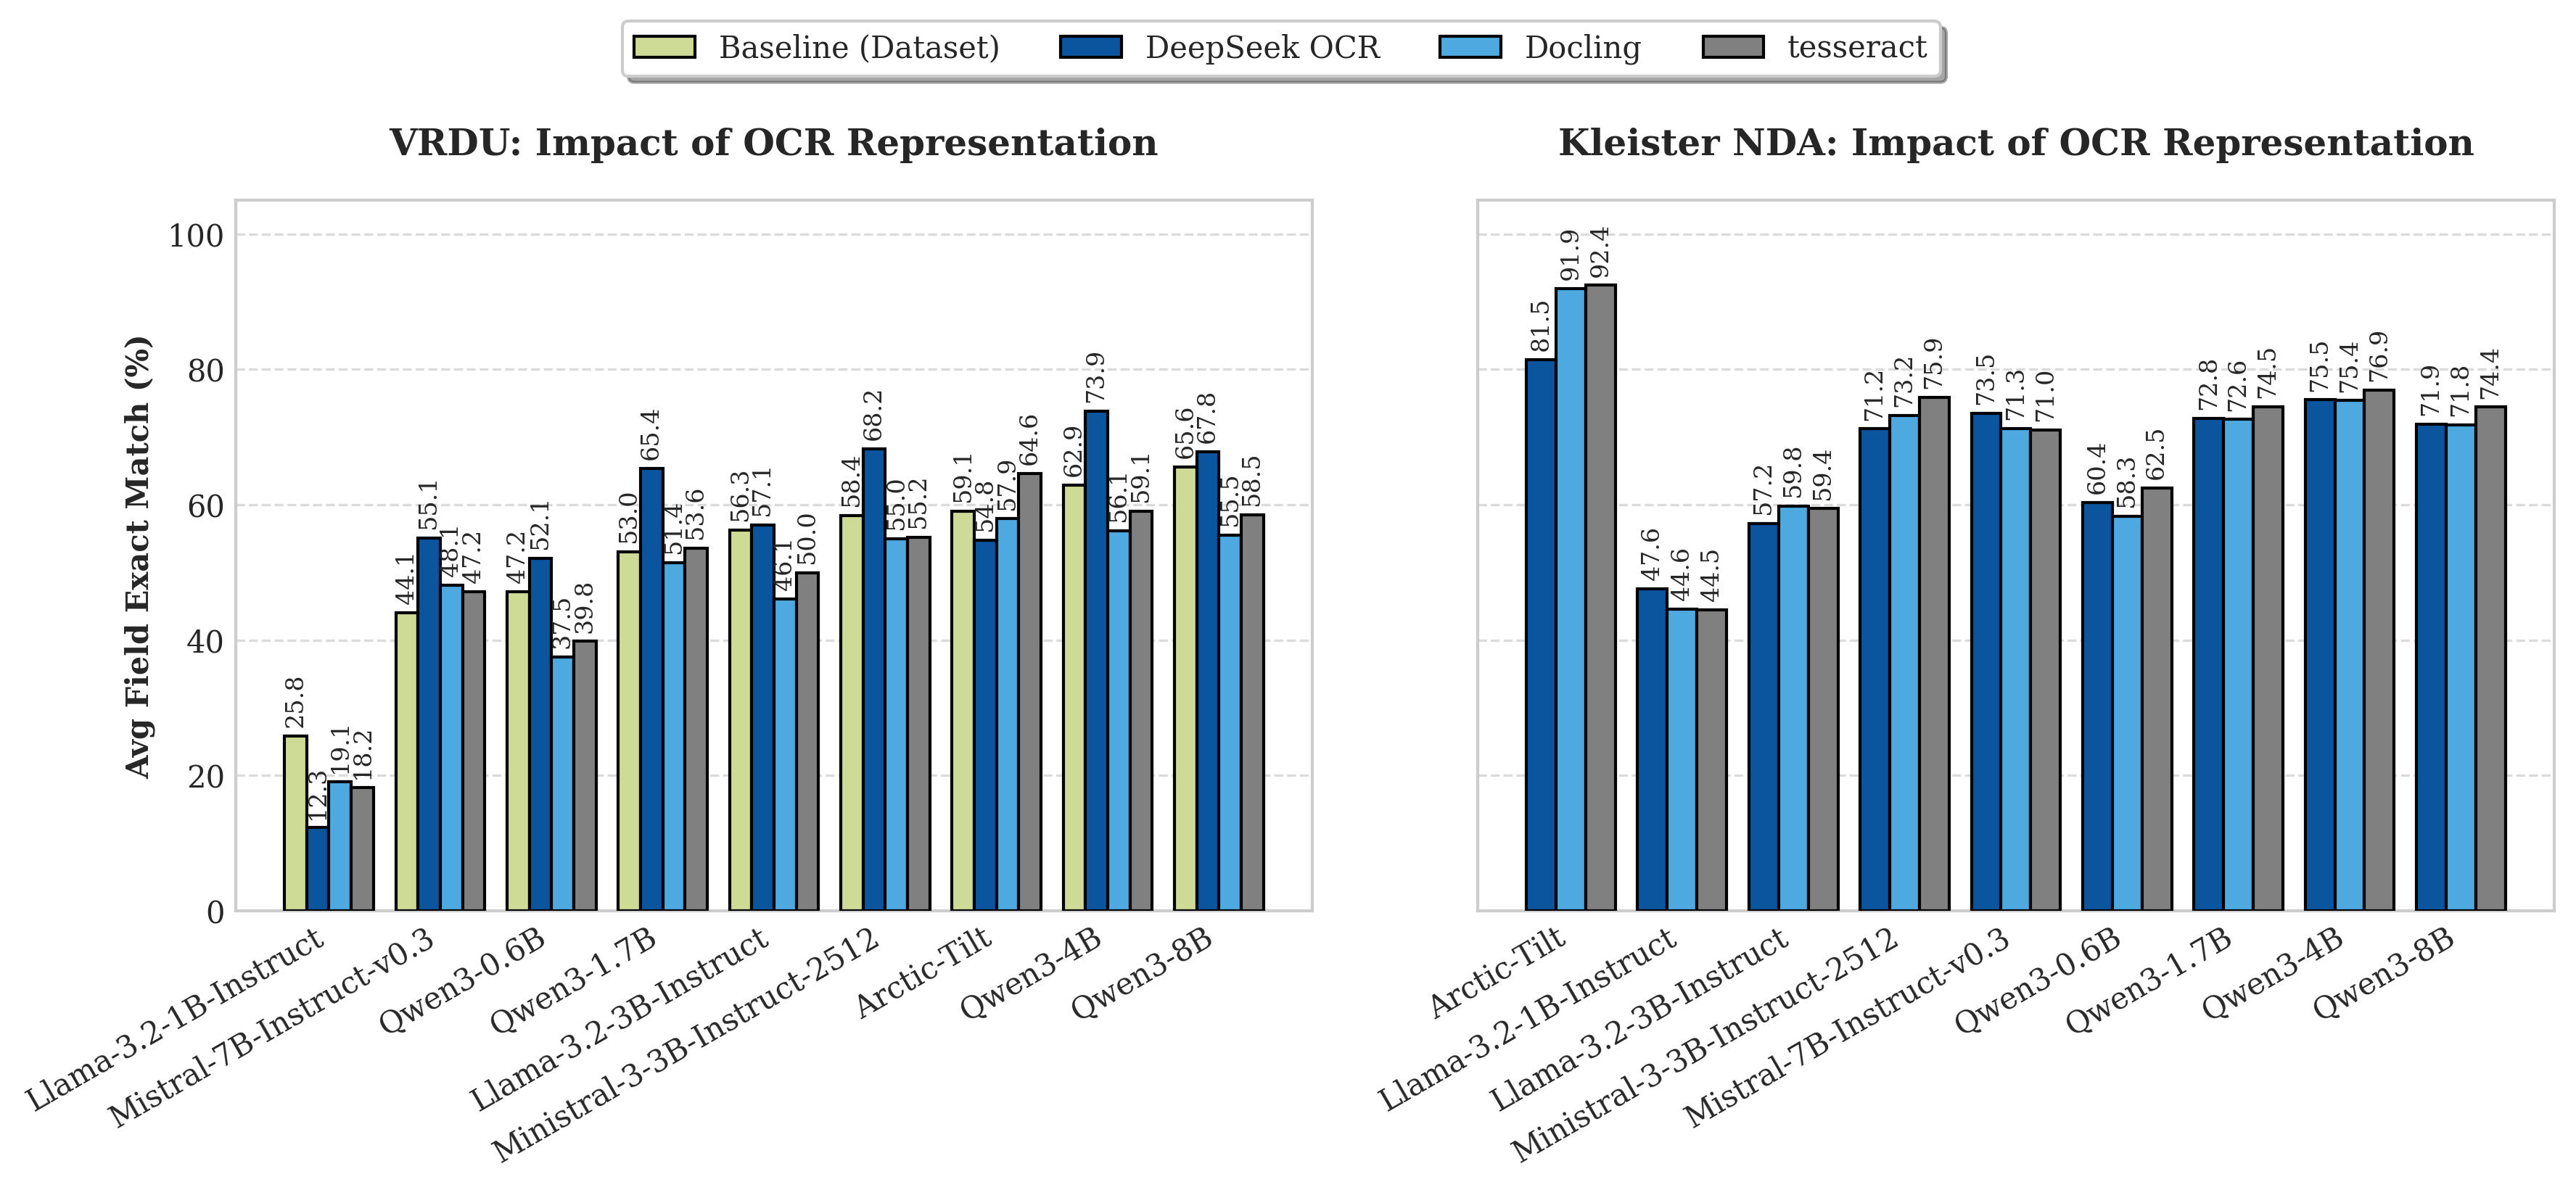

In [6]:
import numpy as np
import matplotlib.pyplot as plt

ocr_colors = {'Baseline (Dataset)': '#cedb97', 'Docling': '#4da9df', 'DeepSeek OCR': '#0b559f'}
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), sharey=True)
datasets = ['VRDU', 'Kleister NDA']

# Dictionary to collect unique handles and labels for the shared legend
legend_elements = {}

for i, dataset_name in enumerate(datasets):
    ax = axes[i]
    df_text = df_all[(df_all['Modality'] == 'Text-Only') & (df_all['Dataset'] == dataset_name)].copy()

    if df_text.empty:
        ax.set_title(f'{dataset_name} (No Data)')
        continue

    df_text_best = df_text.sort_values(by=['Model', 'Task_Clean', 'Accuracy'], ascending=[True, True, False])
    df_text_best = df_text_best.drop_duplicates(subset=['Model', 'Task_Clean'], keep='first').reset_index(drop=True)
    pivot_df = df_text_best.pivot(index='Model', columns='Task_Clean', values='Accuracy').fillna(0)

    if 'Baseline (Dataset)' in pivot_df.columns:
        pivot_df = pivot_df.sort_values('Baseline (Dataset)', ascending=True)
    else:
        pivot_df = pivot_df.sort_index()

    x = np.arange(len(pivot_df.index))
    num_tasks = len(pivot_df.columns)
    width = 0.8 / num_tasks

    for j, task_name in enumerate(pivot_df.columns):
        offset = (j - num_tasks/2) * width + (width/2)
        color = ocr_colors.get(task_name, 'gray')
        rects = ax.bar(x + offset, pivot_df[task_name], width, label=task_name, color=color, edgecolor='black', zorder=3)

        # Save the first rectangle of each task to our legend dictionary
        if task_name not in legend_elements:
            legend_elements[task_name] = rects[0]

        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, rotation=90)

    ax.set_title(f'{dataset_name}: Impact of OCR Representation', pad=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_df.index, rotation=30, ha='right')
    ax.set_ylim(0, 105)

    if i == 0:
        ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold')

    # Individual ax.legend() removed from here

    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.grid(False, axis='x')

# --- New Legend Logic ---
# Add a single shared legend to the figure, placing it above the subplots
fig.legend(legend_elements.values(), legend_elements.keys(),
           loc='lower center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(legend_elements), frameon=True, shadow=True)

plt.tight_layout()

# Adjust the top spacing to make room for the new global legend
plt.subplots_adjust(top=0.92)

plt.savefig('acl_text_tasks_comparison_both_datasets.pdf', format='pdf', bbox_inches='tight')
plt.show()

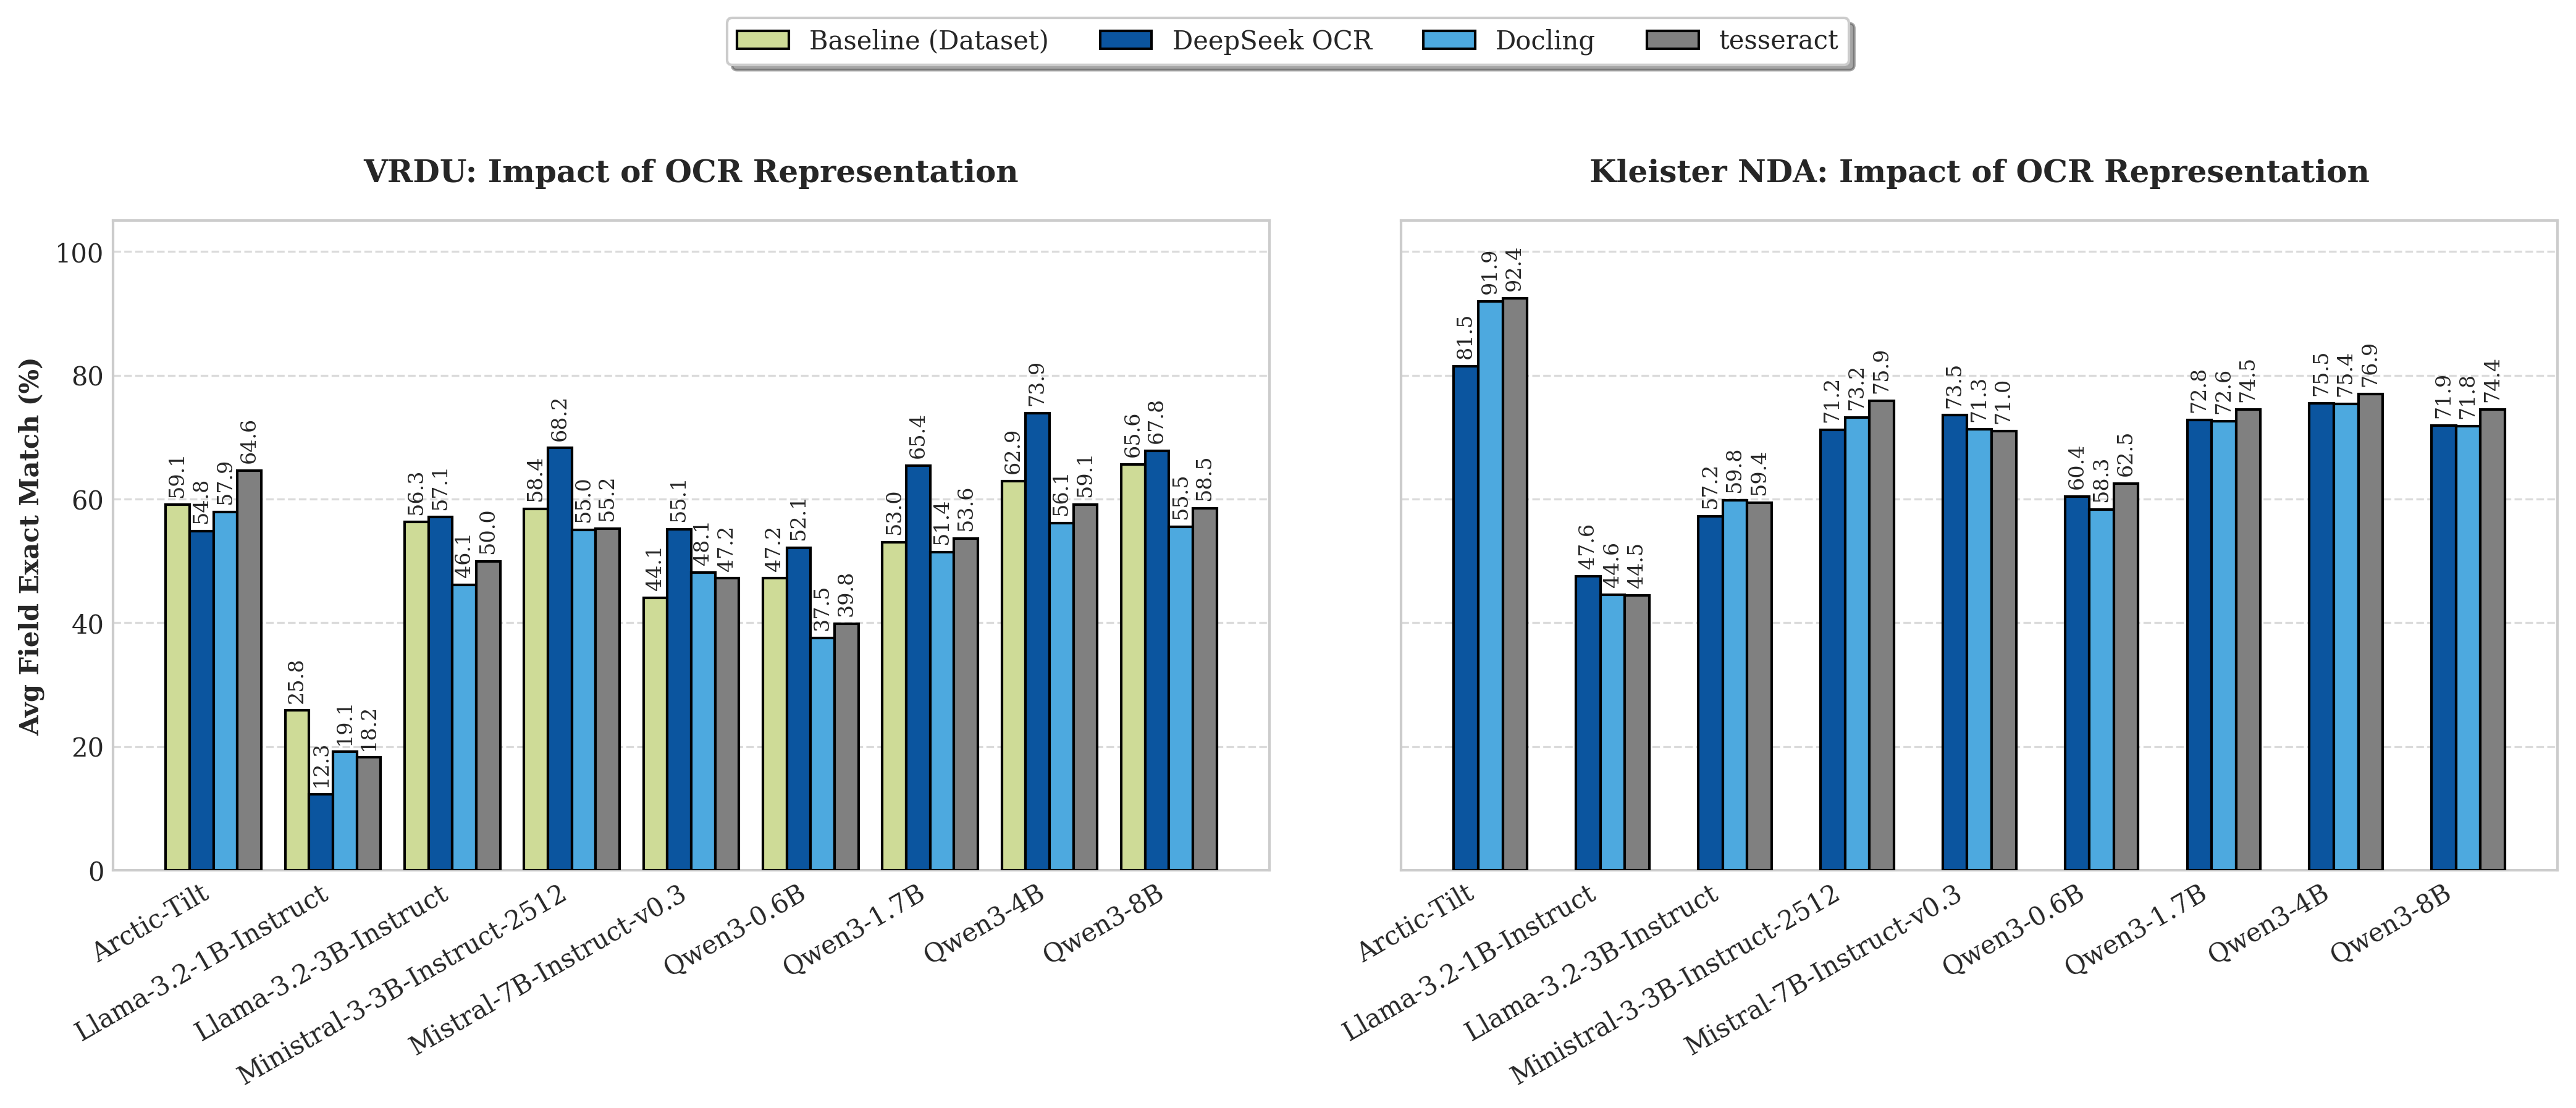

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Defined color palette and task representation order (Vision removed)
ocr_colors = {
    'Baseline (Dataset)': '#cedb97',
    'DeepSeek OCR': '#0b559f',
    'Docling': '#4da9df',
    'tesseract': 'gray',
}

text_tasks = ['Baseline (Dataset)', 'DeepSeek OCR', 'Docling', 'tesseract']
desired_order = text_tasks

# 2. Filter data to exclude Vision models
df_processed = df_all.copy()
df_processed = df_processed[df_processed['Modality'] != 'Vision'].copy()

# Strictly keep only the defined tasks
df_processed = df_processed[df_processed['Task_Clean'].isin(desired_order)].copy()

# 3. Sort models globally by Model name
global_model_order = sorted(df_processed['Model'].unique().tolist())

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.5), sharey=True)
datasets = ['VRDU', 'Kleister NDA']

legend_elements = {}

for i, dataset_name in enumerate(datasets):
  ax = axes[i]

  df_dataset = df_processed[df_processed['Dataset'] == dataset_name].copy()

  if df_dataset.empty:
    ax.set_title(f'{dataset_name} (No Data)')
    continue

  # Deduplicate to get top performance per Model and Task representation
  df_best = df_dataset.sort_values(
      by=['Model', 'Task_Clean', 'Accuracy'], ascending=[True, True, False]
  )
  df_best = df_best.drop_duplicates(
      subset=['Model', 'Task_Clean'], keep='first'
  ).reset_index(drop=True)

  # Pivot table: Rows = Models, Columns = Task Representations
  pivot_df = df_best.pivot(
      index='Model', columns='Task_Clean', values='Accuracy'
  ).fillna(0)

  # Filter global order to ONLY include models that actually have data for this dataset
  dataset_models = df_dataset['Model'].unique()
  plot_models = [m for m in global_model_order if m in dataset_models]
  pivot_df = pivot_df.reindex(index=plot_models, fill_value=0)

  x_positions = np.arange(len(pivot_df.index))

  # Iterate over each model and use a fixed-slot layout for text models
  for model_idx, model in enumerate(pivot_df.index):
      row = pivot_df.loc[model]

      # 4 fixed slots to maintain perfect alignment and show intentional gaps
      bar_width = 0.8 / len(text_tasks)
      start_offset = -0.4 + bar_width / 2

      for j, task_name in enumerate(text_tasks):
          val = row.get(task_name, 0)
          if val > 0:
              offset = start_offset + j * bar_width
              rect = ax.bar(
                  x_positions[model_idx] + offset, val, bar_width,
                  label=task_name if task_name not in legend_elements else "",
                  color=ocr_colors[task_name], edgecolor='black', zorder=3
              )
              if task_name not in legend_elements:
                  legend_elements[task_name] = rect[0]

              ax.annotate(
                  f'{val:.1f}',
                  xy=(rect[0].get_x() + rect[0].get_width() / 2, val),
                  xytext=(0, 3), textcoords='offset points',
                  ha='center', va='bottom', fontsize=8, rotation=90
              )

  ax.set_title(
      f'{dataset_name}: Impact of OCR Representation',
      pad=15,
      fontweight='bold',
  )
  ax.set_xticks(x_positions)
  ax.set_xticklabels(pivot_df.index, rotation=30, ha='right')
  ax.set_ylim(0, 105)

  if i == 0:
    ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold')

  ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
  ax.grid(False, axis='x')

# Figure-level legend
ordered_keys = [k for k in desired_order if k in legend_elements]
fig.legend(
    [legend_elements[k] for k in ordered_keys],
    ordered_keys,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(ordered_keys),
    frameon=True,
    shadow=True,
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig(
    'acl_text_tasks_comparison_both_datasets.pdf',
    format='pdf',
    bbox_inches='tight',
)
plt.show()

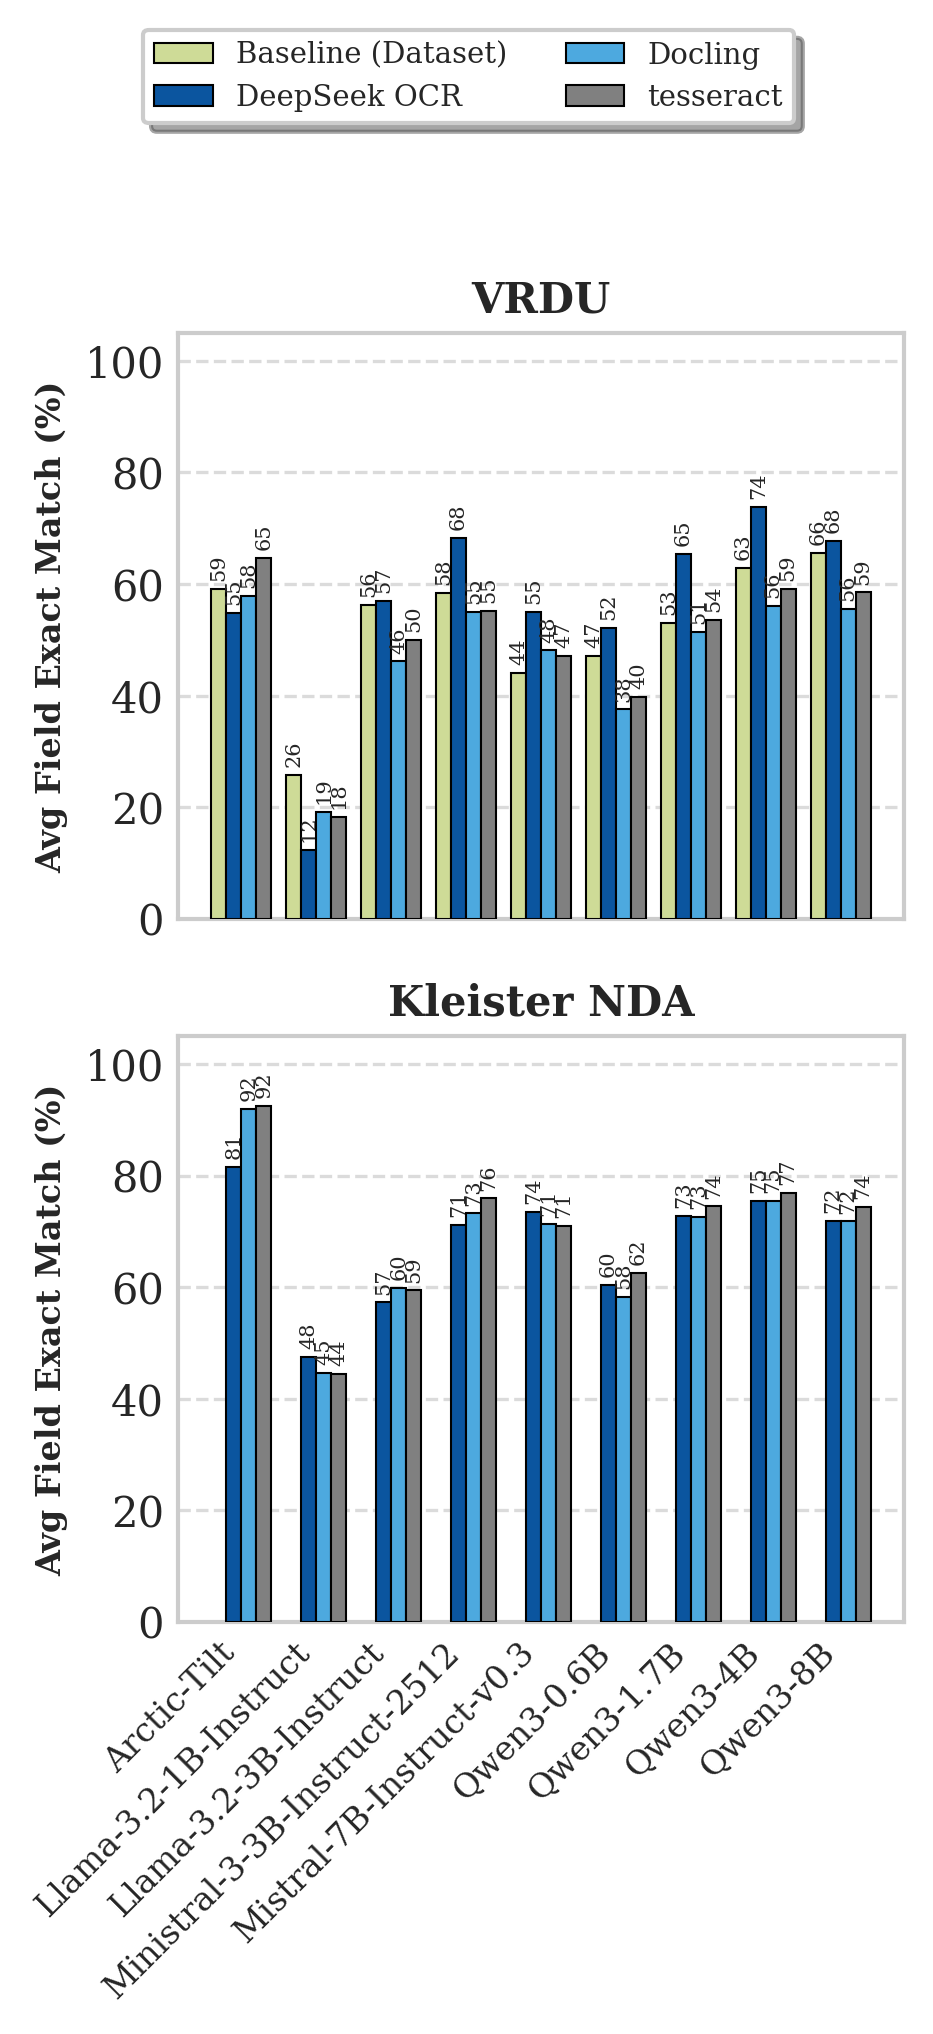

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Defined color palette and task representation order (Vision removed)
ocr_colors = {
    'Baseline (Dataset)': '#cedb97',
    'DeepSeek OCR': '#0b559f',
    'Docling': '#4da9df',
    'tesseract': 'gray',
}

text_tasks = ['Baseline (Dataset)', 'DeepSeek OCR', 'Docling', 'tesseract']
desired_order = text_tasks

# 2. Filter data to exclude Vision models
df_processed = df_all.copy()
df_processed = df_processed[df_processed['Modality'] != 'Vision'].copy()

# Strictly keep only the defined tasks
df_processed = df_processed[df_processed['Task_Clean'].isin(desired_order)].copy()

# 3. Sort models globally by Model name
global_model_order = sorted(df_processed['Model'].unique().tolist())

# CHANGE: Added sharex=True to remove middle overlapping labels and adjusted height
fig, axes = plt.subplots(2, 1, figsize=(3.2, 6.5), sharey=True, sharex=True)
datasets = ['VRDU', 'Kleister NDA']

legend_elements = {}

for i, dataset_name in enumerate(datasets):
  ax = axes[i]

  df_dataset = df_processed[df_processed['Dataset'] == dataset_name].copy()

  if df_dataset.empty:
    ax.set_title(f'{dataset_name} (No Data)')
    continue

  # Deduplicate to get top performance per Model and Task representation
  df_best = df_dataset.sort_values(
      by=['Model', 'Task_Clean', 'Accuracy'], ascending=[True, True, False]
  )
  df_best = df_best.drop_duplicates(
      subset=['Model', 'Task_Clean'], keep='first'
  ).reset_index(drop=True)

  # Pivot table: Rows = Models, Columns = Task Representations
  pivot_df = df_best.pivot(
      index='Model', columns='Task_Clean', values='Accuracy'
  ).fillna(0)

  # Filter global order to ONLY include models that actually have data for this dataset
  dataset_models = df_dataset['Model'].unique()
  plot_models = [m for m in global_model_order if m in dataset_models]
  pivot_df = pivot_df.reindex(index=plot_models, fill_value=0)

  x_positions = np.arange(len(pivot_df.index))

  # Iterate over each model and use a fixed-slot layout for text models
  for model_idx, model in enumerate(pivot_df.index):
      row = pivot_df.loc[model]

      # 4 fixed slots to maintain perfect alignment and show intentional gaps
      bar_width = 0.8 / len(text_tasks)
      start_offset = -0.4 + bar_width / 2

      for j, task_name in enumerate(text_tasks):
          val = row.get(task_name, 0)
          if val > 0:
              offset = start_offset + j * bar_width
              rect = ax.bar(
                  x_positions[model_idx] + offset, val, bar_width,
                  label=task_name if task_name not in legend_elements else "",
                  color=ocr_colors[task_name], edgecolor='black',
                  linewidth=0.5, zorder=3
              )
              if task_name not in legend_elements:
                  legend_elements[task_name] = rect[0]

              # CHANGE: Formatted to 0 decimal places (.0f) and dropped fontsize to 5
              ax.annotate(
                  f'{val:.0f}',
                  xy=(rect[0].get_x() + rect[0].get_width() / 2, val),
                  xytext=(0, 2), textcoords='offset points',
                  ha='center', va='bottom', fontsize=5, rotation=90
              )

  # Title for each subplot
  ax.set_title(
      f'{dataset_name}',
      pad=5,
      fontweight='bold',
      fontsize=10
  )

  ax.set_xticks(x_positions)

  # CHANGE: Only apply x-labels to the bottom plot to prevent collision
  if i == 1:
      ax.set_xticklabels(pivot_df.index, rotation=45, ha='right', fontsize=8)

  ax.set_ylim(0, 105)
  ax.set_ylabel('Avg Field Exact Match (%)', fontweight='bold', fontsize=8)

  ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
  ax.grid(False, axis='x')

# Figure-level legend
ordered_keys = [k for k in desired_order if k in legend_elements]
fig.legend(
    [legend_elements[k] for k in ordered_keys],
    ordered_keys,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=True,
    shadow=True,
    fontsize=7
)

# tight_layout handles the spacing perfectly now that sharex=True is used
plt.tight_layout()
plt.subplots_adjust(top=0.88, hspace=0.2)

plt.savefig(
    'acl_text_tasks_comparison_both_datasets.pdf',
    format='pdf',
    bbox_inches='tight',
)
plt.show()

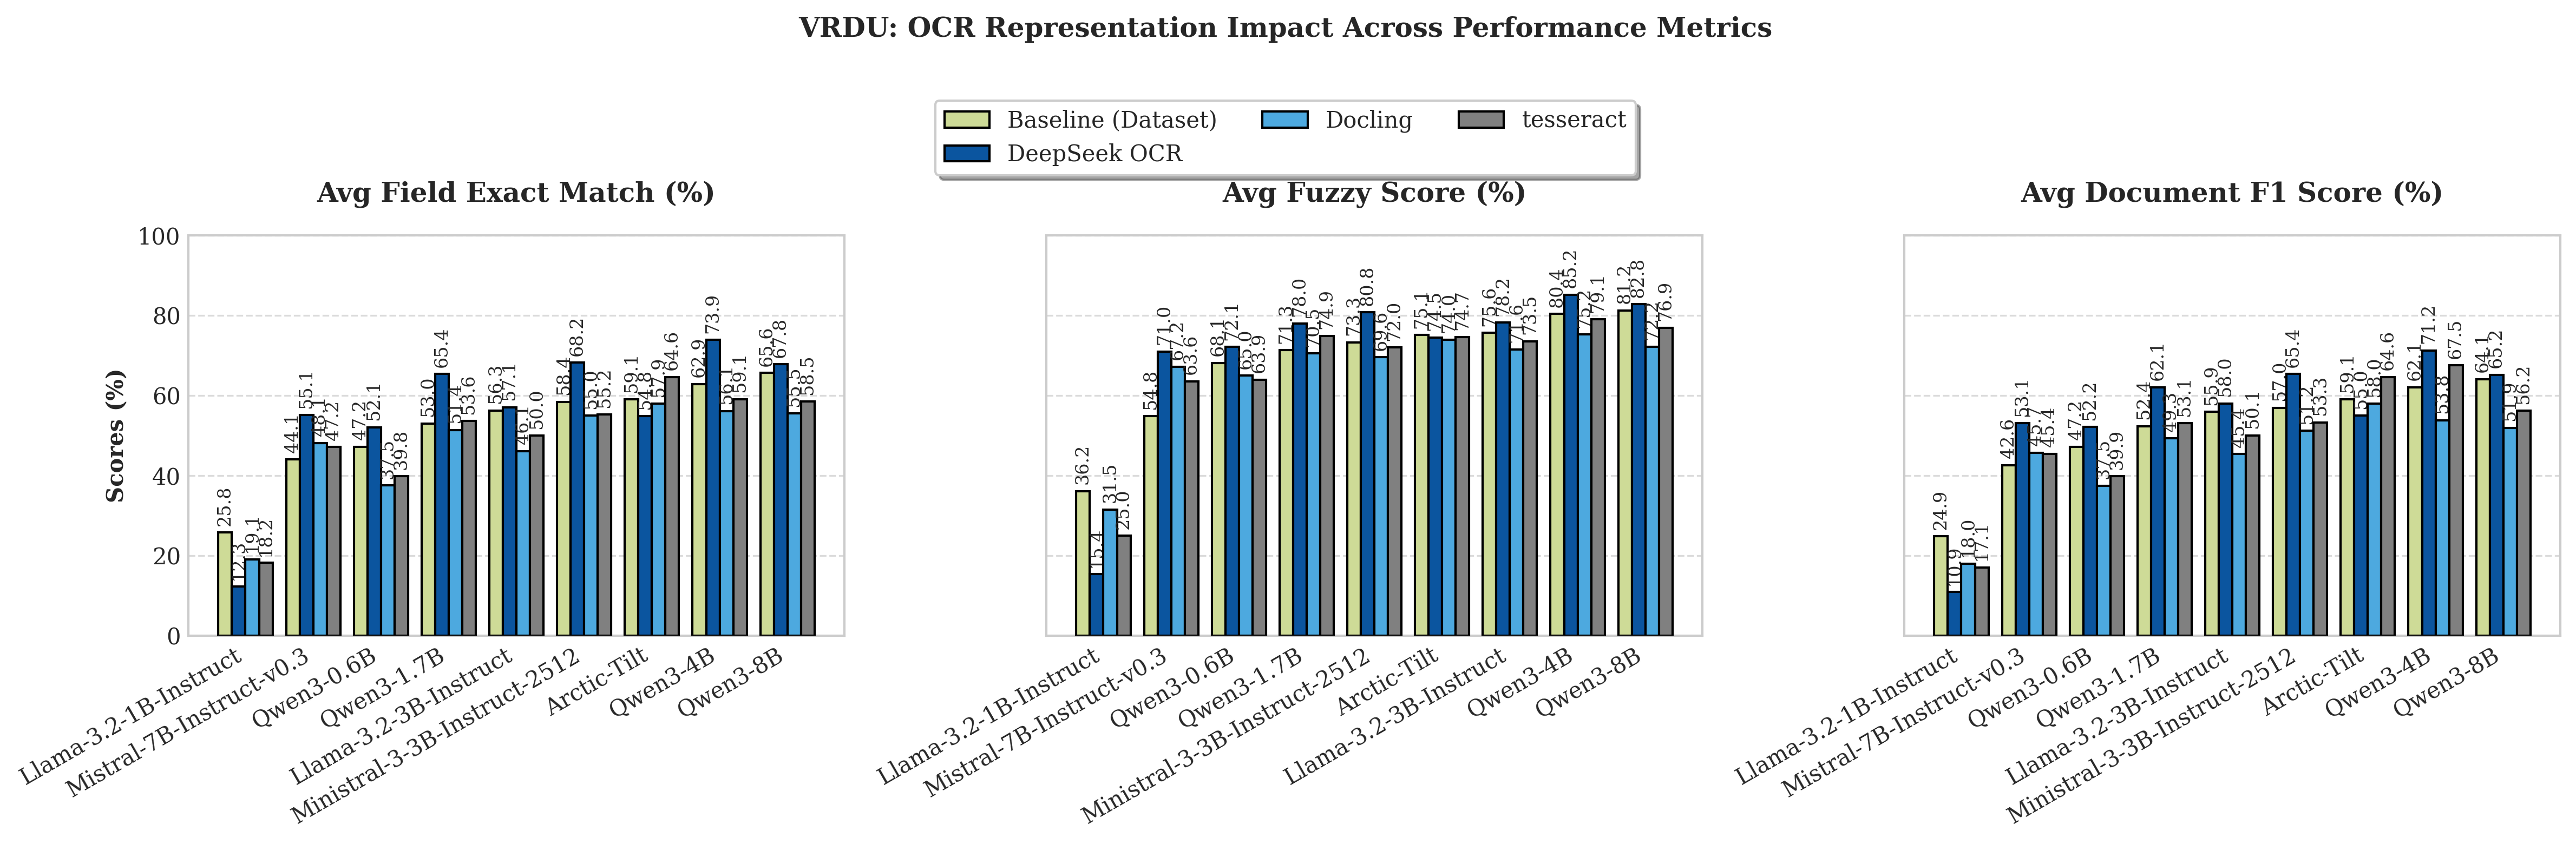

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0), sharey=True)
metrics = ['Exact_Match', 'Fuzzy_Match', 'F1_Score']
metric_labels = ['Avg Field Exact Match (%)', 'Avg Fuzzy Score (%)', 'Avg Document F1 Score (%)']
ocr_colors = {'Baseline (Dataset)': '#cedb97', 'Docling': '#4da9df', 'DeepSeek OCR': '#0b559f'}

# Filter for Text-Only models on the VRDU dataset
df_text = df_all[(df_all['Modality'] == 'Text-Only') & (df_all['Dataset'] == 'VRDU')].copy()

if df_text.empty:
    print("No VRDU Text-Only data matched requirements.")
else:
    for i, metric in enumerate(metrics):
        ax = axes[i]
        df_text_best = df_text.sort_values(by=['Model', 'Task_Clean', metric], ascending=[True, True, False])
        df_text_best = df_text_best.drop_duplicates(subset=['Model', 'Task_Clean'], keep='first').reset_index(drop=True)
        pivot_df = df_text_best.pivot(index='Model', columns='Task_Clean', values=metric).fillna(0)

        if 'Baseline (Dataset)' in pivot_df.columns:
            pivot_df = pivot_df.sort_values('Baseline (Dataset)', ascending=True)
        else:
            pivot_df = pivot_df.sort_index()

        x = np.arange(len(pivot_df.index))
        num_tasks = len(pivot_df.columns)
        width = 0.8 / num_tasks

        for j, task_name in enumerate(pivot_df.columns):
            offset = (j - num_tasks/2) * width + (width/2)
            color = ocr_colors.get(task_name, 'gray')
            rects = ax.bar(x + offset, pivot_df[task_name], width, label=task_name, color=color, edgecolor='black', zorder=3)

            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, rotation=90)

        ax.set_title(metric_labels[i], pad=15, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot_df.index, rotation=30, ha='right')

        # Increased Y-axis limit to 120 to prevent annotation clipping
        ax.set_ylim(0, 100)

        if i == 0:
            ax.set_ylabel('Scores (%)', fontweight='bold')

        # Removed the individual ax.legend() call here
        ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
        ax.grid(False, axis='x')

    # Extract handles and labels from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()

    # Create a single figure-level legend placed top-center, arranged horizontally
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=3, frameon=True, shadow=True)

    # Push the super title up slightly to make room
    plt.suptitle('VRDU: OCR Representation Impact Across Performance Metrics', fontsize=12, fontweight='bold', y=1.03)

    # Use the `rect` parameter in tight_layout to leave empty space at the top
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.savefig('vrdu_multi_metrics_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()

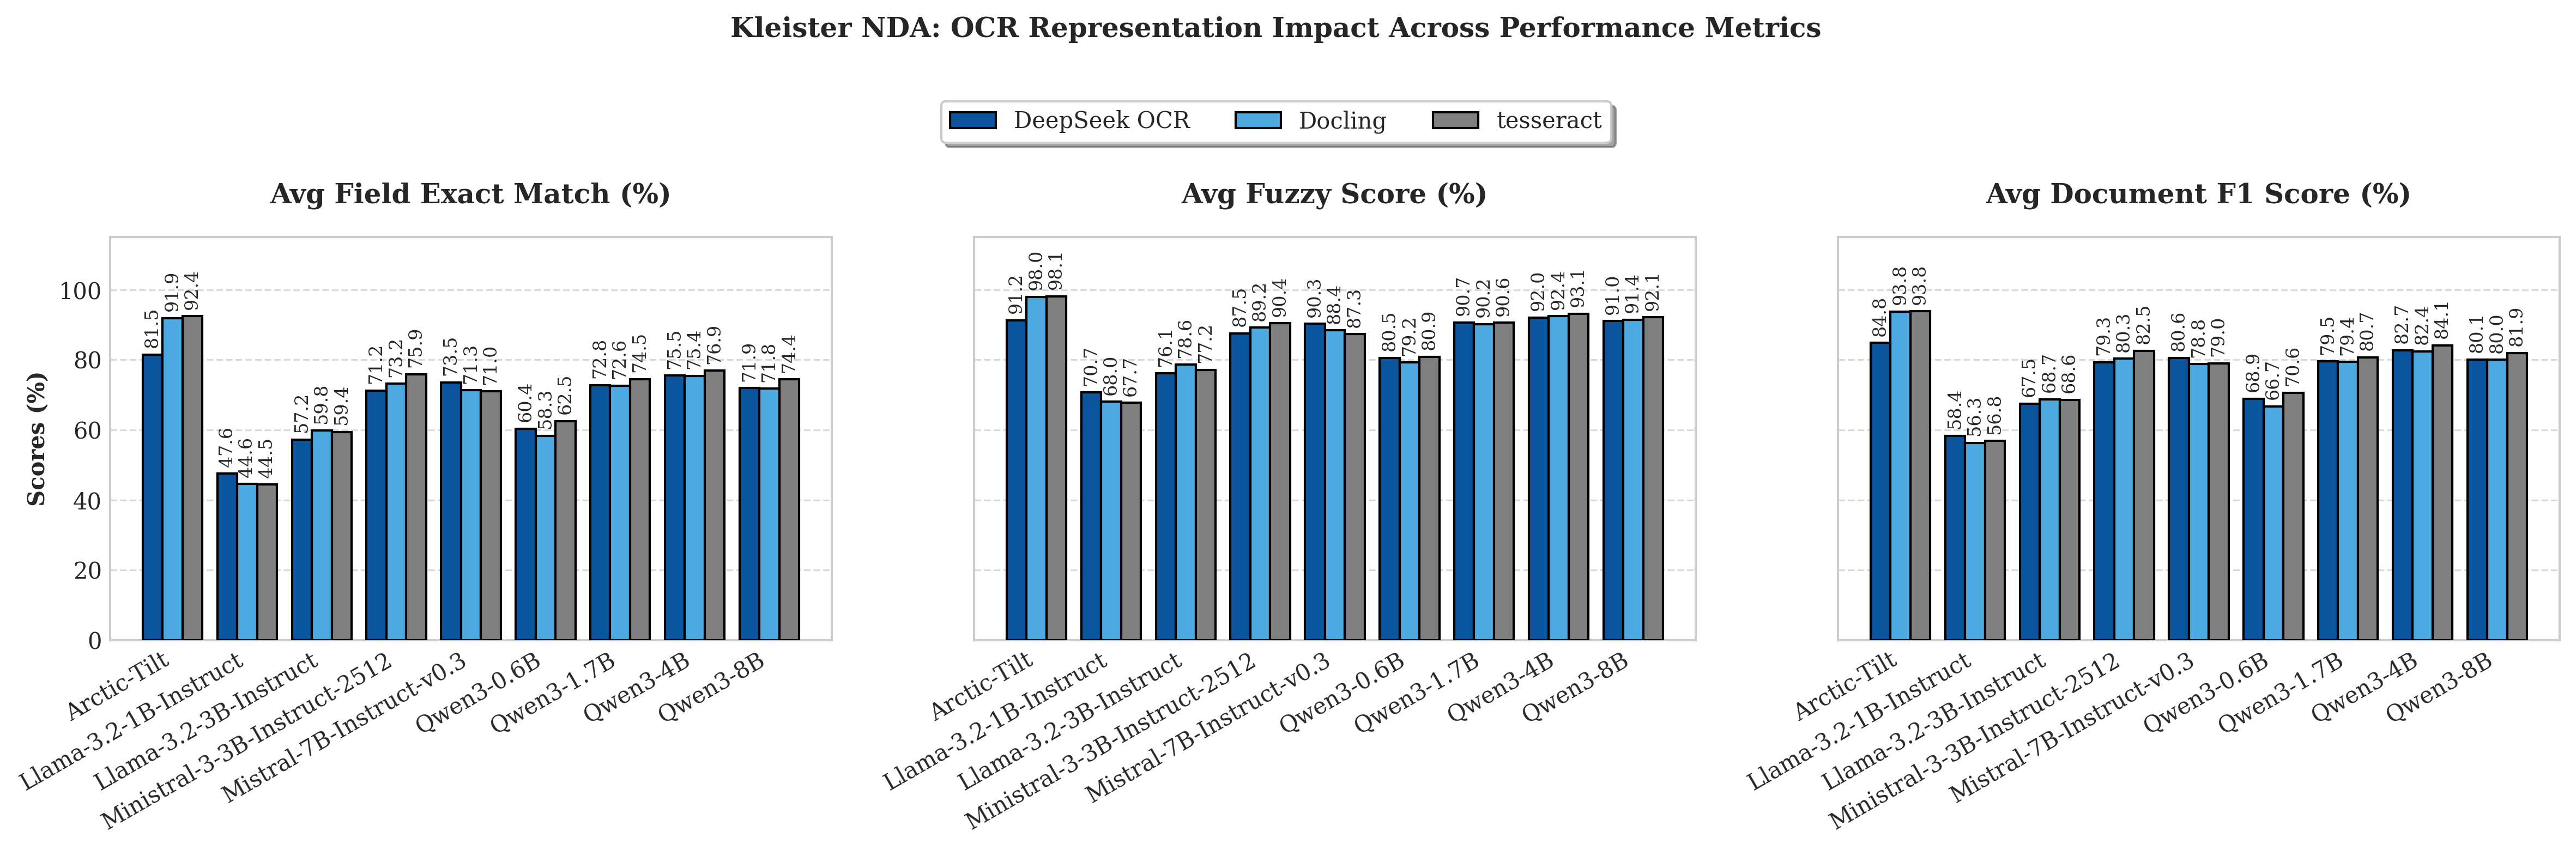

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0), sharey=True)
metrics = ['Exact_Match', 'Fuzzy_Match', 'F1_Score']
metric_labels = ['Avg Field Exact Match (%)', 'Avg Fuzzy Score (%)', 'Avg Document F1 Score (%)']

df_text = df_all[(df_all['Modality'] == 'Text-Only') & (df_all['Dataset'] == 'Kleister NDA')].copy()

if df_text.empty:
    print("No Kleister NDA Text-Only data matched requirements.")
else:
    for i, metric in enumerate(metrics):
        ax = axes[i]
        df_text_best = df_text.sort_values(by=['Model', 'Task_Clean', metric], ascending=[True, True, False])
        df_text_best = df_text_best.drop_duplicates(subset=['Model', 'Task_Clean'], keep='first').reset_index(drop=True)
        pivot_df = df_text_best.pivot(index='Model', columns='Task_Clean', values=metric).fillna(0)

        if 'Baseline (Dataset)' in pivot_df.columns:
            pivot_df = pivot_df.sort_values('Baseline (Dataset)', ascending=True)
        else:
            pivot_df = pivot_df.sort_index()

        x = np.arange(len(pivot_df.index))
        num_tasks = len(pivot_df.columns)
        width = 0.8 / num_tasks

        for j, task_name in enumerate(pivot_df.columns):
            offset = (j - num_tasks/2) * width + (width/2)
            color = ocr_colors.get(task_name, 'gray')
            rects = ax.bar(x + offset, pivot_df[task_name], width, label=task_name, color=color, edgecolor='black', zorder=3)

            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8, rotation=90)

        ax.set_title(metric_labels[i], pad=15, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot_df.index, rotation=30, ha='right')

        # INCREASED Y-AXIS LIMIT HERE TO PREVENT CLIPPING
        ax.set_ylim(0, 115)

        if i == 0:
            ax.set_ylabel('Scores (%)', fontweight='bold')

        ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
        ax.grid(False, axis='x')

    # Extract handles and labels from the first subplot
    handles, labels = axes[0].get_legend_handles_labels()

    # Create a single figure-level legend placed top-center, arranged horizontally
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), ncol=3, frameon=True, shadow=True)

    # Push the super title up slightly to make room
    plt.suptitle('Kleister NDA: OCR Representation Impact Across Performance Metrics', fontsize=12, fontweight='bold', y=1.03)

    # Use the `rect` parameter in tight_layout to leave empty space at the top (top 8% reserved for title/legend)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    plt.savefig('kleister_nda_multi_metrics_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()

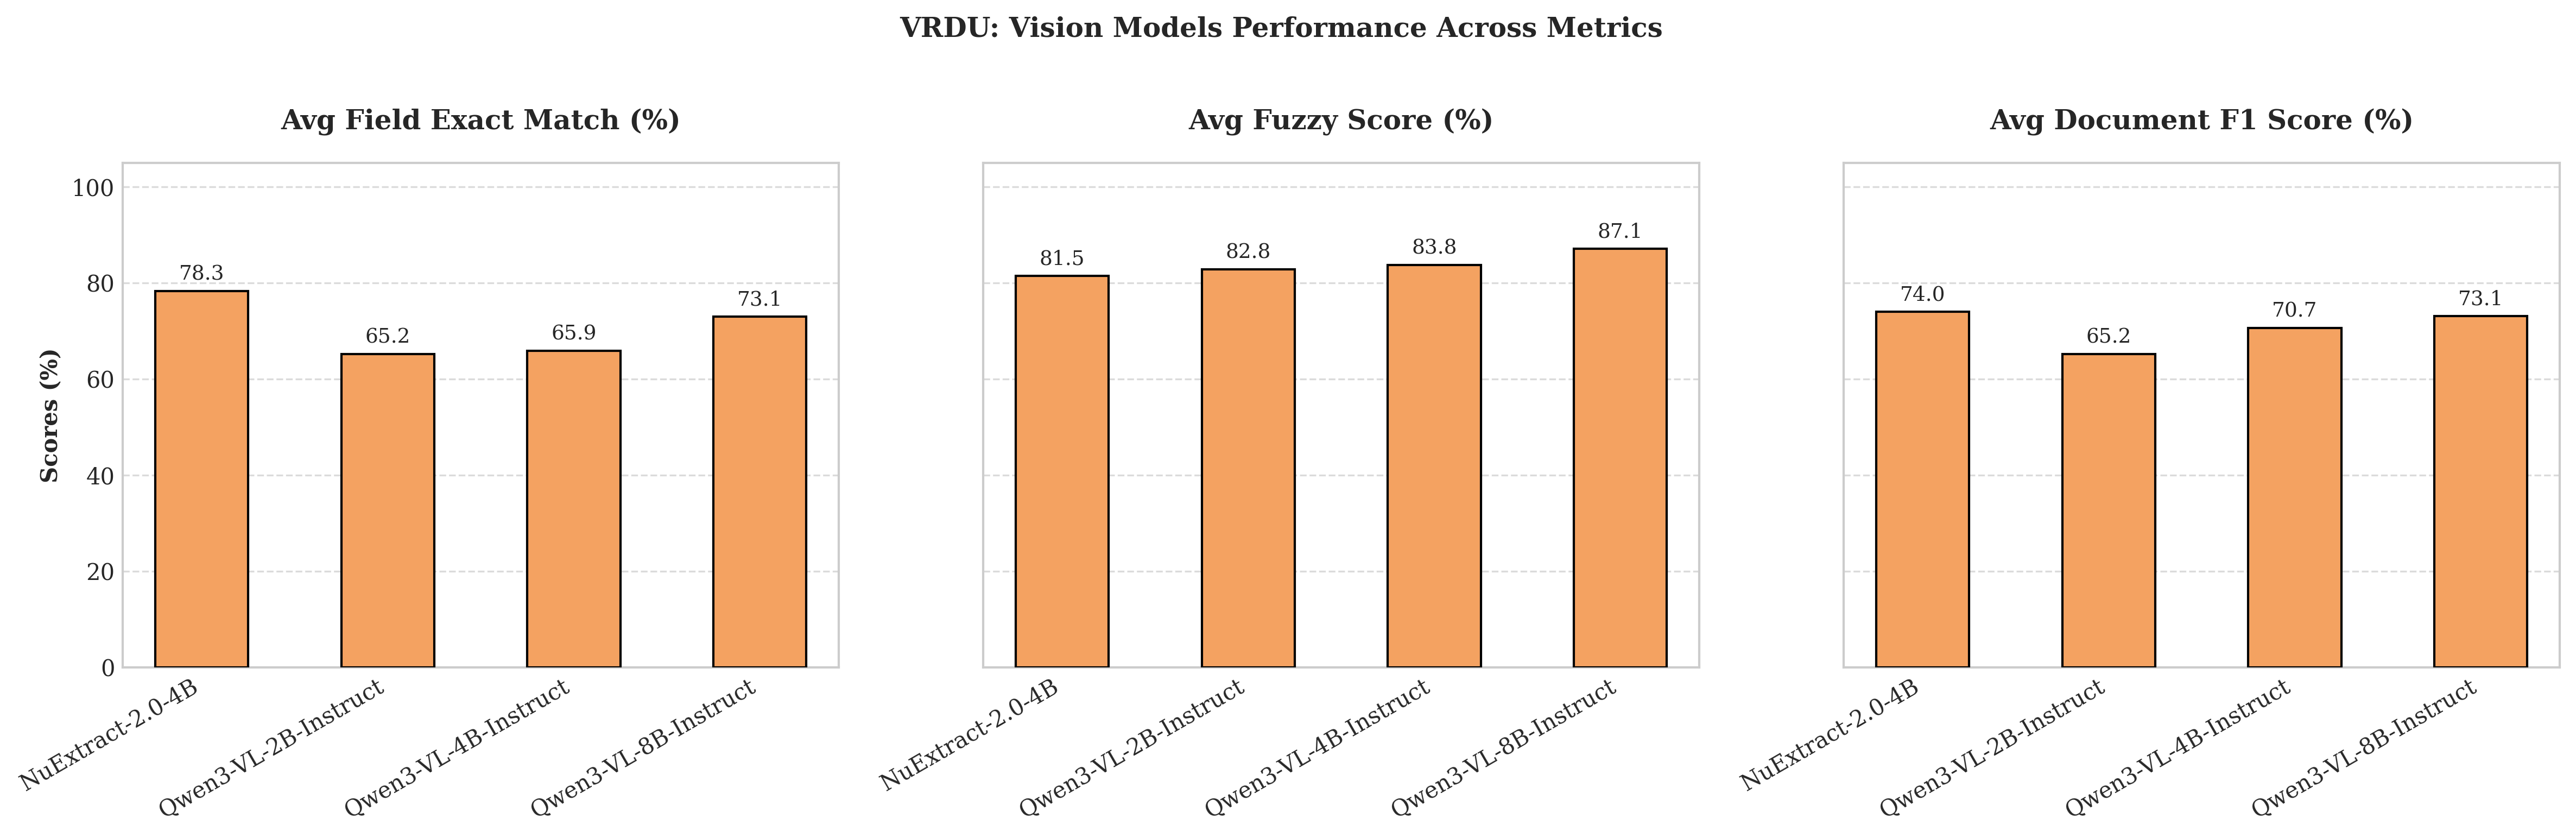

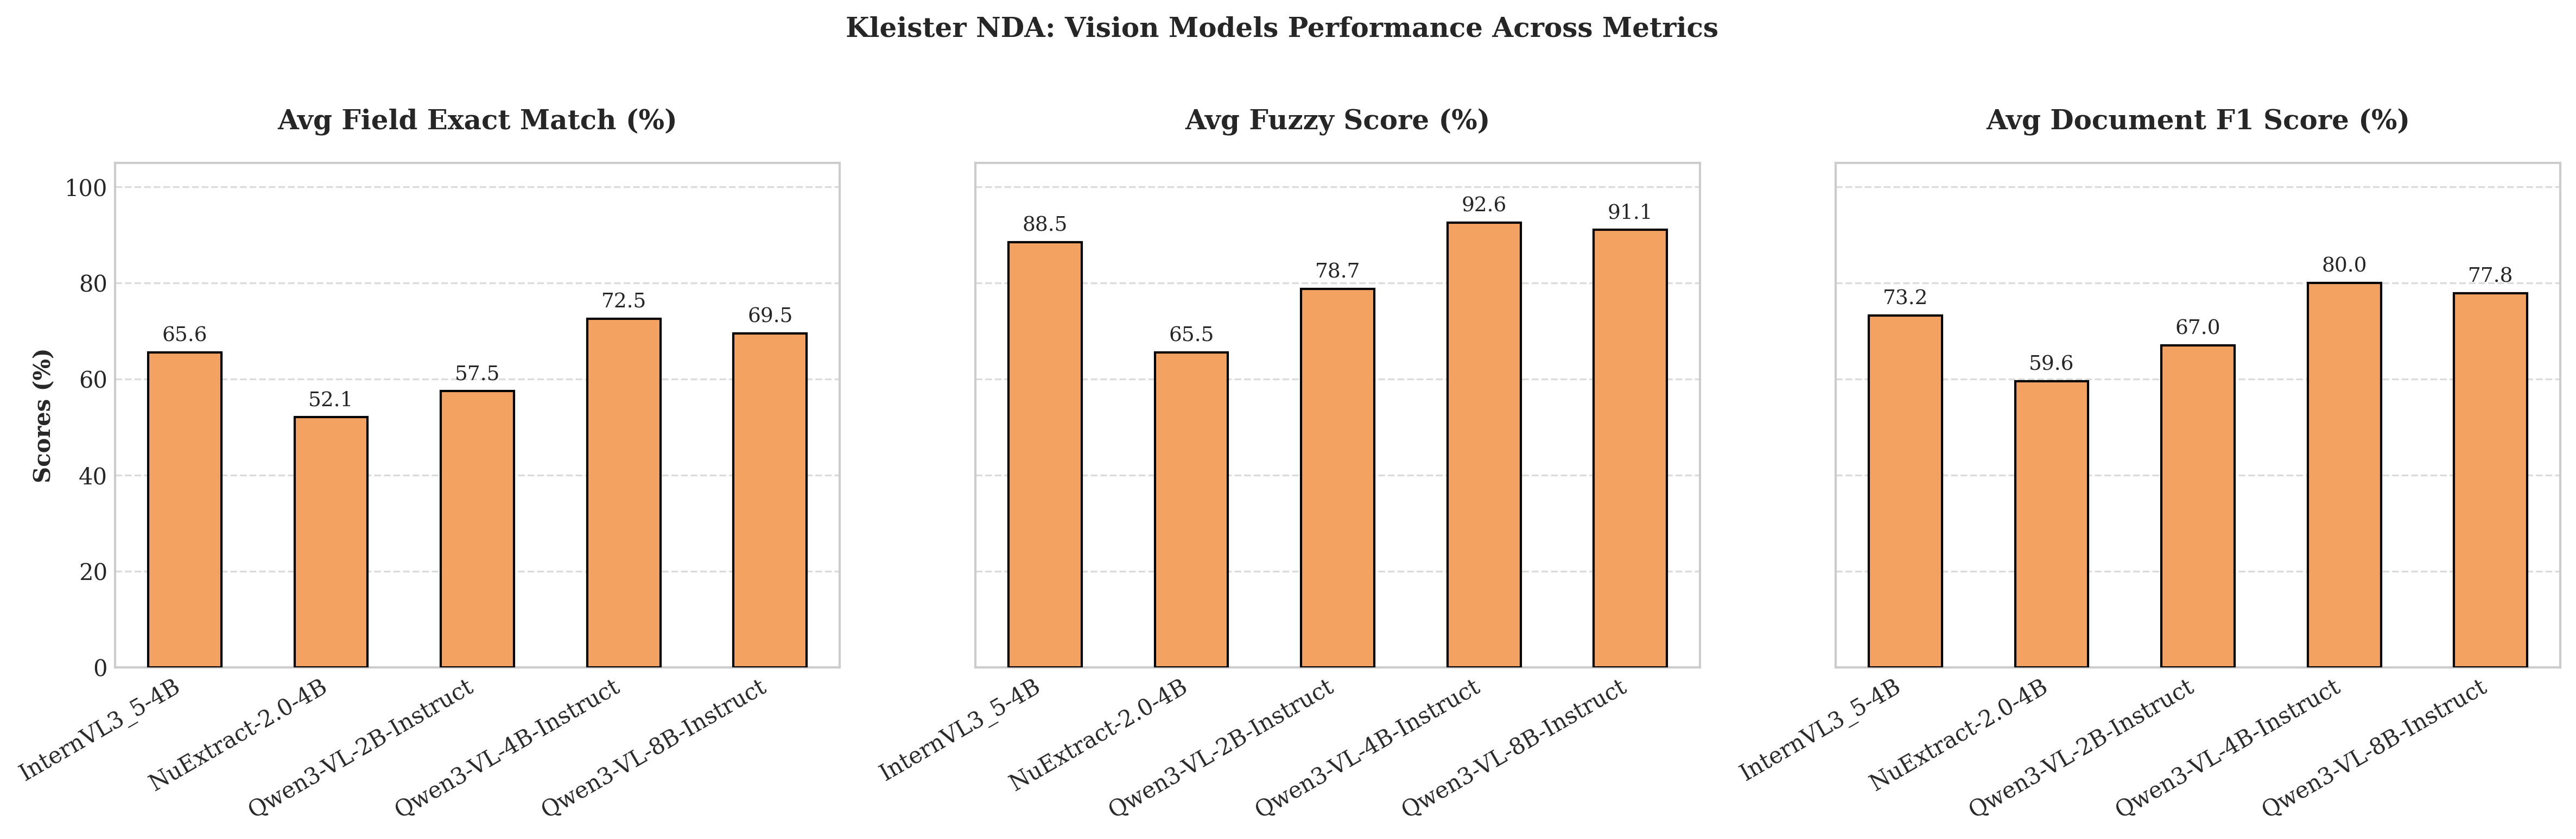

In [10]:
datasets = ['VRDU', 'Kleister NDA']
metrics = ['Exact_Match', 'Fuzzy_Match', 'F1_Score']
metric_labels = ['Avg Field Exact Match (%)', 'Avg Fuzzy Score (%)', 'Avg Document F1 Score (%)']
vision_color = '#f4a261' # Same orange from your vision scripts

for dataset_name in datasets:
    # Filter for Native Vision models for the current dataset
    df_vision = df_all[(df_all['Modality'] == 'Vision') & (df_all['Dataset'] == dataset_name)].copy()

    if df_vision.empty:
        print(f"No {dataset_name} Vision data matched requirements.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(16.0, 5.0), sharey=True)

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Get best performance for each model on this specific metric
        df_vision_best = df_vision.sort_values(by=['Model', metric], ascending=[True, False])
        df_vision_best = df_vision_best.drop_duplicates(subset=['Model'], keep='first').sort_values('Model').reset_index(drop=True)

        x = np.arange(len(df_vision_best['Model']))
        width = 0.5

        # Plot standard bars since there are no OCR sub-tasks
        rects = ax.bar(x, df_vision_best[metric], width, color=vision_color, edgecolor='black', zorder=3)

        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

        ax.set_title(metric_labels[i], pad=15, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(df_vision_best['Model'], rotation=30, ha='right')
        ax.set_ylim(0, 105)

        if i == 0:
            ax.set_ylabel('Scores (%)', fontweight='bold')

        ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
        ax.grid(False, axis='x')

    plt.suptitle(f'{dataset_name}: Vision Models Performance Across Metrics', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save a PDF dynamically based on the dataset name
    file_prefix = dataset_name.lower().replace(" ", "_")
    plt.savefig(f'{file_prefix}_vision_multi_metrics_comparison.pdf', format='pdf', bbox_inches='tight')
    plt.show()

In [12]:
 df_all[df_all['Model'] == "arctic-tilt"]


,Dataset,Model,Batch_Size,Exact_Match,Accuracy,Fuzzy_Match,F1_Score,Energy_Wh,Modality,Task,Backend,File_Path,Task_Clean


In [13]:
import pandas as pd
import re

# 1. Load the new energy report using your custom cleaner function to avoid parser errors
energy_raw = load_cleaned_energy_report('../arctic_results/inference_energy_report.csv')

# 2. Filter for rows where dataset_name ends with an underscore and digits (e.g., _1, _5)
df_batch_energy = energy_raw[energy_raw['dataset_name'].str.contains(r'_\d+$', na=False, regex=True)].copy()

# 3. Extract the batch size directly from the dataset_name string
df_batch_energy['Batch_Size'] = df_batch_energy['dataset_name'].str.extract(r'_(\d+)$').astype(int)

# 4. Map the messy dataset_name back to your standard naming convention
def clean_dataset_name(name):
    if 'vrdu' in str(name).lower():
        return 'VRDU'
    if 'kleister' in str(name).lower():
        return 'Kleister NDA'
    return 'Unknown'

df_batch_energy['Dataset'] = df_batch_energy['dataset_name'].apply(clean_dataset_name)

# 5. Standardize the remaining columns to match df_all
df_batch_energy['Model'] = 'Arctic-Tilt'
df_batch_energy['Modality'] = 'Text-Only'
df_batch_energy['Backend'] = 'vllm'

# --- THE CHANGE IS HERE ---
# Use 'gpu_energy' instead of 'energy_consumed'
df_batch_energy['Energy_Wh'] = df_batch_energy['gpu_energy'] * 1000
# -------------------------

# 6. GUARANTEE: Remove any existing Arctic-Tilt data from df_all so we don't mix old/new
df_all_no_arctic = df_all[df_all['Model'] != 'Arctic-Tilt'].copy()

# 7. Merge the cleaned base data with ONLY the newly extracted Arctic-Tilt data
cols_to_keep = ['Dataset', 'Model', 'Batch_Size', 'Energy_Wh', 'Modality', 'Backend']
df_plot_ready = pd.concat([df_all_no_arctic, df_batch_energy[cols_to_keep]], ignore_index=True)

print(f"Removed old Arctic-Tilt data and added {len(df_batch_energy)} strictly filtered rows (GPU Energy ONLY) for the final plot!")

Removed old Arctic-Tilt data and added 6 strictly filtered rows (GPU Energy ONLY) for the final plot!


Successfully updated Arctic-Tilt VRDU Tesseract data from ../arctic_results/energy_batch_size.csv


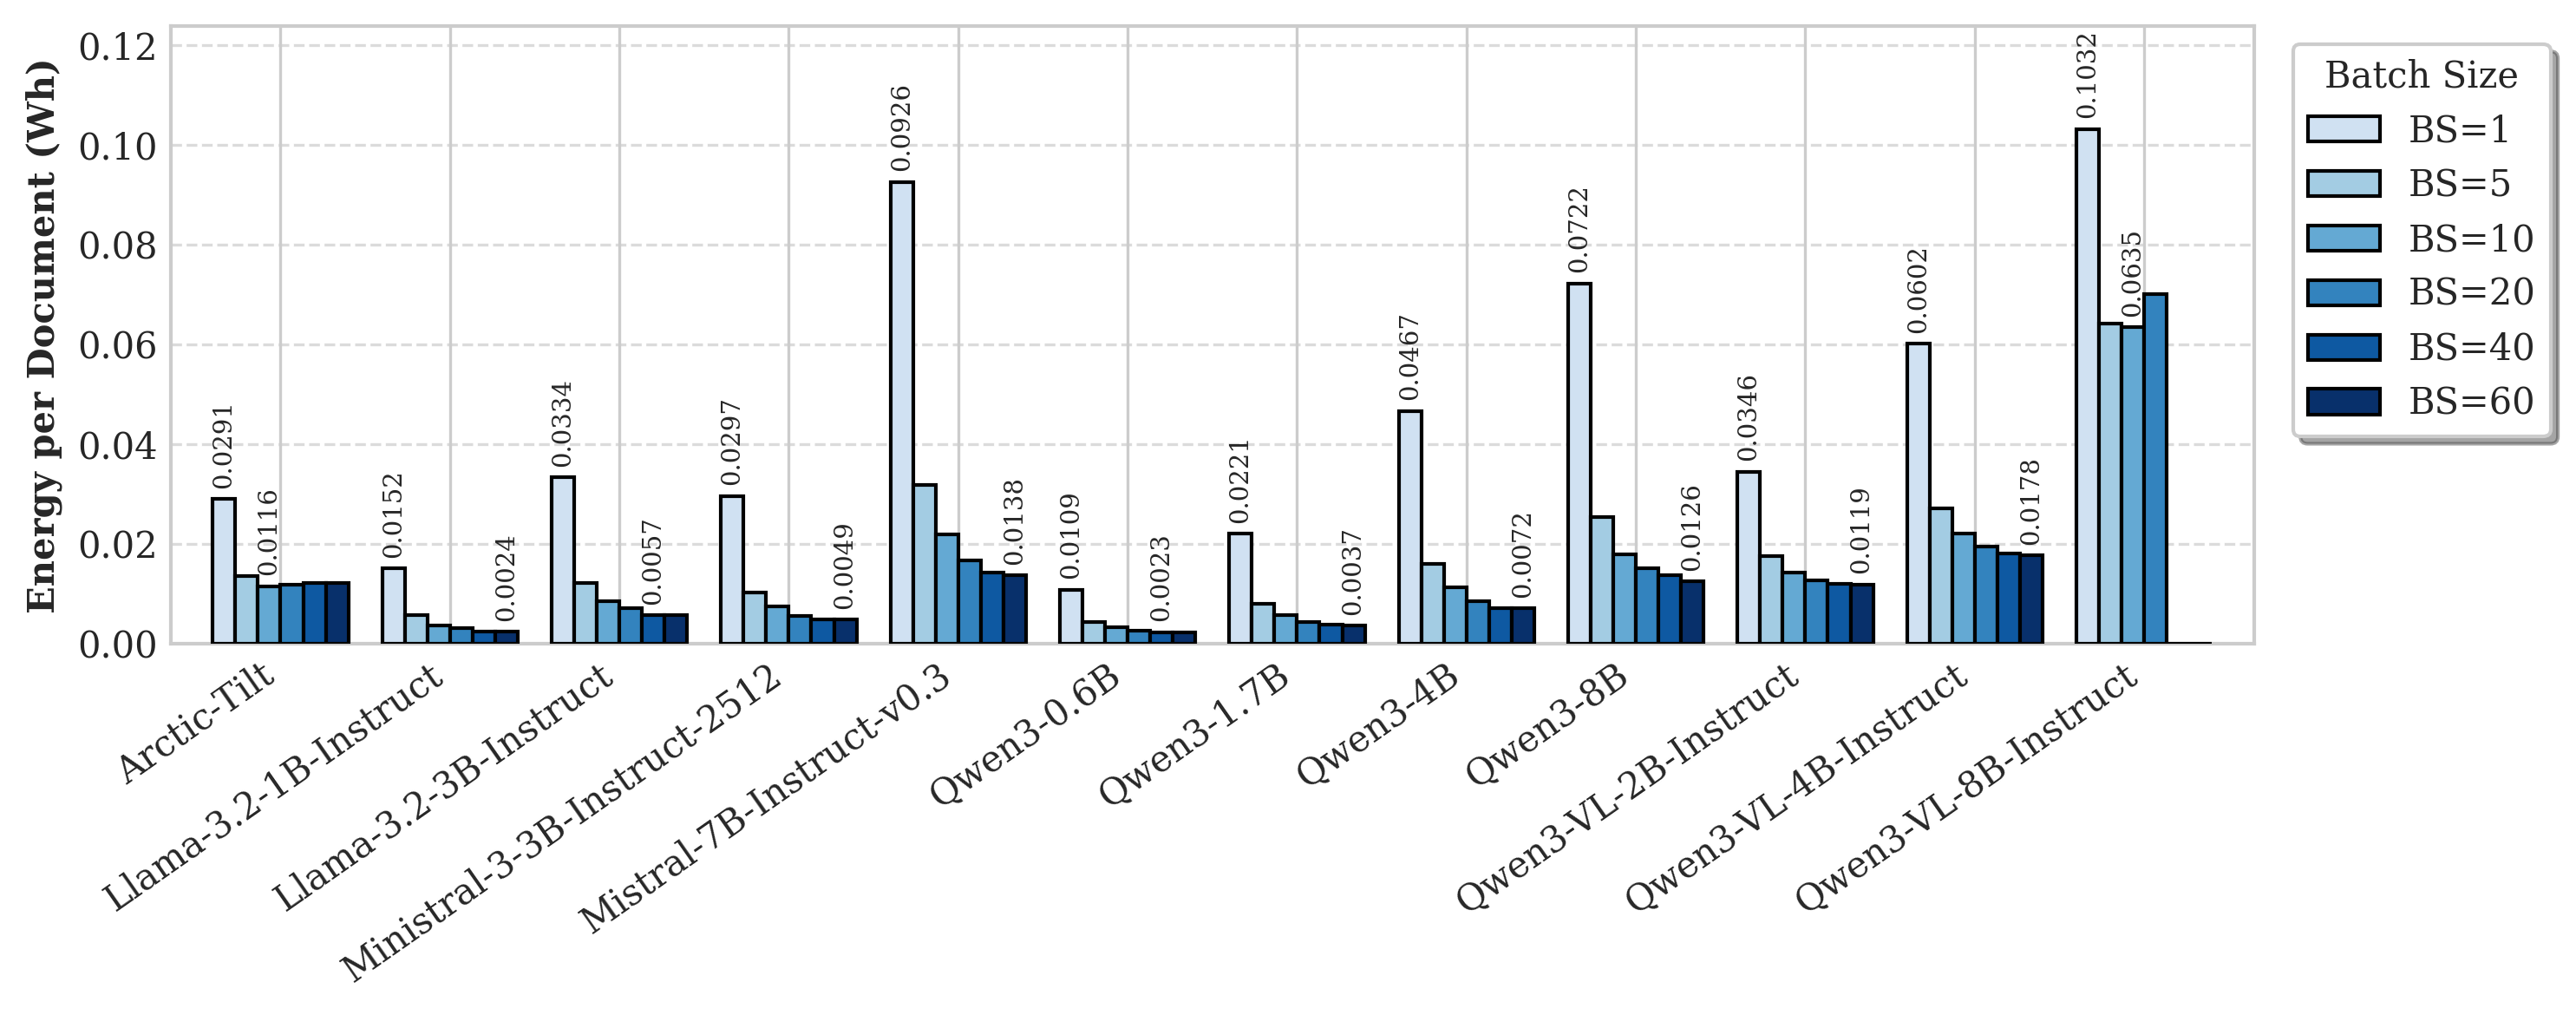

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. INJECT ARCTIC-TILT TESSERACT DATA
# =============================================================================
energy_bs_path = '../arctic_results/energy_batch_size.csv'
try:
    tesseract_energy = pd.read_csv(energy_bs_path)

    # Remove existing Arctic-Tilt / VRDU / Tesseract data to prevent duplicates
    mask = (
        (df_plot_ready['Dataset'] == 'VRDU') &
        (df_plot_ready['Model'] == 'Arctic-Tilt') &
        (df_plot_ready['Task'].astype(str).str.lower() == 'tesseract')
    )
    df_plot_ready = df_plot_ready[~mask]

    # Construct replacement rows
    new_rows = []
    for _, row in tesseract_energy.iterrows():
        batch_size = float(row['batch_size'])
        energy_wh = float(row['energy_consumed']) * 1000  # Convert kWh to Wh

        new_rows.append({
            'Dataset': 'VRDU',
            'Model': 'Arctic-Tilt',
            'Batch_Size': batch_size,
            'Energy_Wh': energy_wh,
            'Modality': 'Text-Only',
            'Backend': 'vllm',
            'Task': 'tesseract',
            'Task_Clean': 'Tesseract',
            'File_Path': np.nan # Explicitly set as NaN so it passes the unquant filter
        })

    # Append the updated data back into the main plotting DataFrame
    df_plot_ready = pd.concat([df_plot_ready, pd.DataFrame(new_rows)], ignore_index=True)
    print(f"Successfully updated Arctic-Tilt VRDU Tesseract data from {energy_bs_path}")

except Exception as e:
    print(f"Failed to load or process {energy_bs_path}: {e}")

# =============================================================================
# 2. PLOTTING (SINGLE CONFIGURATION: VRDU, VLLM, TESSERACT)
# =============================================================================
TEST_SET_SIZES = {
    'VRDU': 500,
    'Kleister NDA': 337
}

dataset_name = 'VRDU'
backend_name = 'vllm'

# --- NEW QUANTIZATION FILTER ---
# Keep rows where File_Path has 'noquant' OR is NaN (for Arctic/benchmark standalone data)
unquant_mask = (
    df_plot_ready['File_Path'].isna() |
    df_plot_ready['File_Path'].astype(str).str.contains('noquant', case=False, na=False)
)
df_plot_ready_unquant = df_plot_ready[unquant_mask].copy()

# Create Color Palette (using the filtered dataframe so colors map correctly)
all_unique_bs = sorted(df_plot_ready_unquant['Batch_Size'].unique())
cmap = plt.get_cmap('Blues')
color_array = cmap(np.linspace(0.2, 1.0, len(all_unique_bs)))
bs_color_map = {f"BS={int(bs)}": color_array[i] for i, bs in enumerate(all_unique_bs)}

# Filter down strictly to VRDU and vLLM
df_filtered = df_plot_ready_unquant[(df_plot_ready_unquant['Dataset'] == dataset_name) & (df_plot_ready_unquant['Backend'] == backend_name)].copy()
df_compare = df_filtered[df_filtered['Modality'].isin(['Text-Only', 'Vision'])].copy()

if not df_compare.empty:
    # --- APPLY TESSERACT FILTER ---
    # Keep Vision models, Text-Only models using 'tesseract', and Arctic-Tilt using 'tesseract'
    is_vision = df_compare['Modality'] == 'Vision'
    is_tesseract = (df_compare['Modality'] == 'Text-Only') & (df_compare['Task'].astype(str).str.lower() == 'tesseract')
    is_arctic_tesseract = (df_compare['Model'] == 'Arctic-Tilt') & (df_compare['Task'].astype(str).str.lower() == 'tesseract')

    df_compare = df_compare[is_vision | is_tesseract | is_arctic_tesseract].copy()

if not df_compare.empty:
    # NORMALIZE ENERGY HERE BEFORE GROUPING
    df_compare['Energy_per_Doc_Wh'] = df_compare['Energy_Wh'] / TEST_SET_SIZES.get(dataset_name, 1)

    # Replace any residual 0.0 dummy values with NaN so .min() ignores them
    df_compare['Energy_per_Doc_Wh'] = df_compare['Energy_per_Doc_Wh'].replace(0.0, np.nan)

    # Group by normalized column instead of raw Wh
    df_grouped = df_compare.groupby(['Model', 'Batch_Size'])['Energy_per_Doc_Wh'].min().unstack().fillna(0)
    df_grouped.columns = [f"BS={int(c)}" for c in df_grouped.columns]

    fig, ax = plt.subplots(figsize=(10.0, 4.0))
    colors = [bs_color_map.get(col, 'gray') for col in df_grouped.columns]

    df_grouped.plot(kind='bar', color=colors, edgecolor='black', width=0.8, ax=ax, zorder=3)

    # Labels and Titles (Updated to indicate unquantized)
    #ax.set_title(f'{dataset_name} ({backend_name.upper()}): Energy per Document (Tesseract OCR - Unquantized)', pad=15, fontweight='bold')
    ax.set_ylabel('Energy per Document (Wh)', fontweight='bold')

    ax.set_xticklabels(df_grouped.index, rotation=35, ha='right')
    ax.legend(title='Batch Size', loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True, shadow=True)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

    # Data Labels (Min/Max per Group)
    df_masked = df_grouped.replace(0, np.nan)
    row_mins = df_masked.min(axis=1)
    row_maxs = df_masked.max(axis=1)

    for col_idx, container in enumerate(ax.containers):
        labels = []
        for row_idx, rect in enumerate(container):
            val = rect.get_height()
            model_name = df_grouped.index[row_idx]

            is_min = val > 0 and abs(val - row_mins[model_name]) < 1e-6
            is_max = val > 0 and abs(val - row_maxs[model_name]) < 1e-6

            if is_min or is_max:
                labels.append(f'{val:.4f}')
            else:
                labels.append('')

        ax.bar_label(container, labels=labels, padding=3, rotation=90, fontsize=7)

    ax.margins(y=0.2)
    ax.set_xlabel('')
    plt.tight_layout()

    # Updated filename so it doesn't overwrite your previous plots
    filename = f'acl_energy_per_doc_by_batch_size_{dataset_name.lower()}_{backend_name.lower()}_tesseract_unquant.pdf'
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(f"No valid unquantized data found to plot for {dataset_name} using {backend_name} with Tesseract filter.")

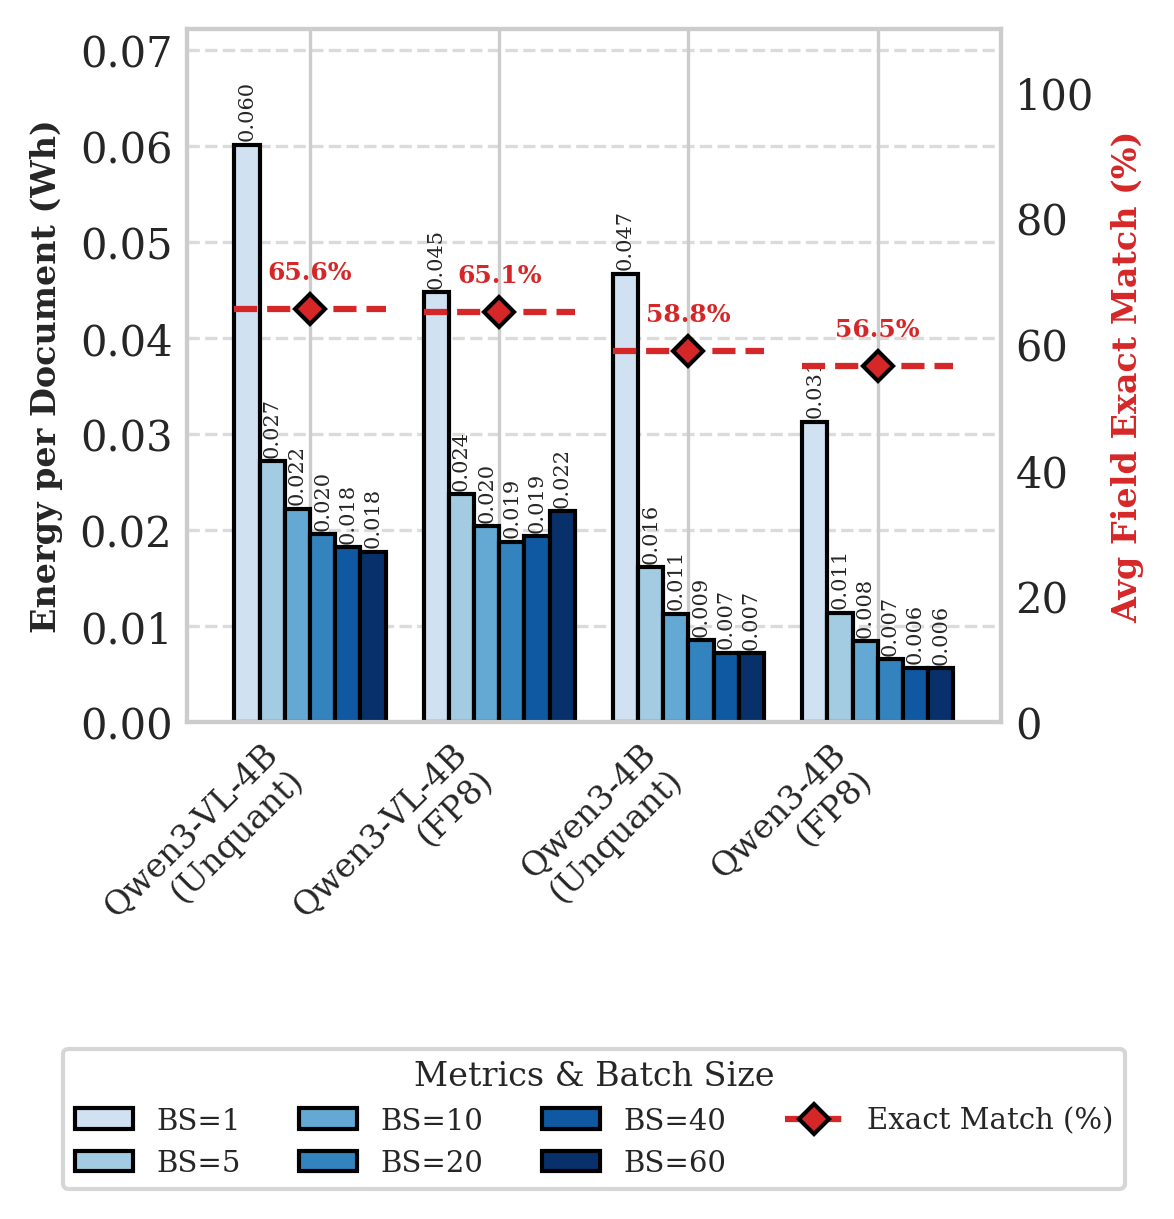

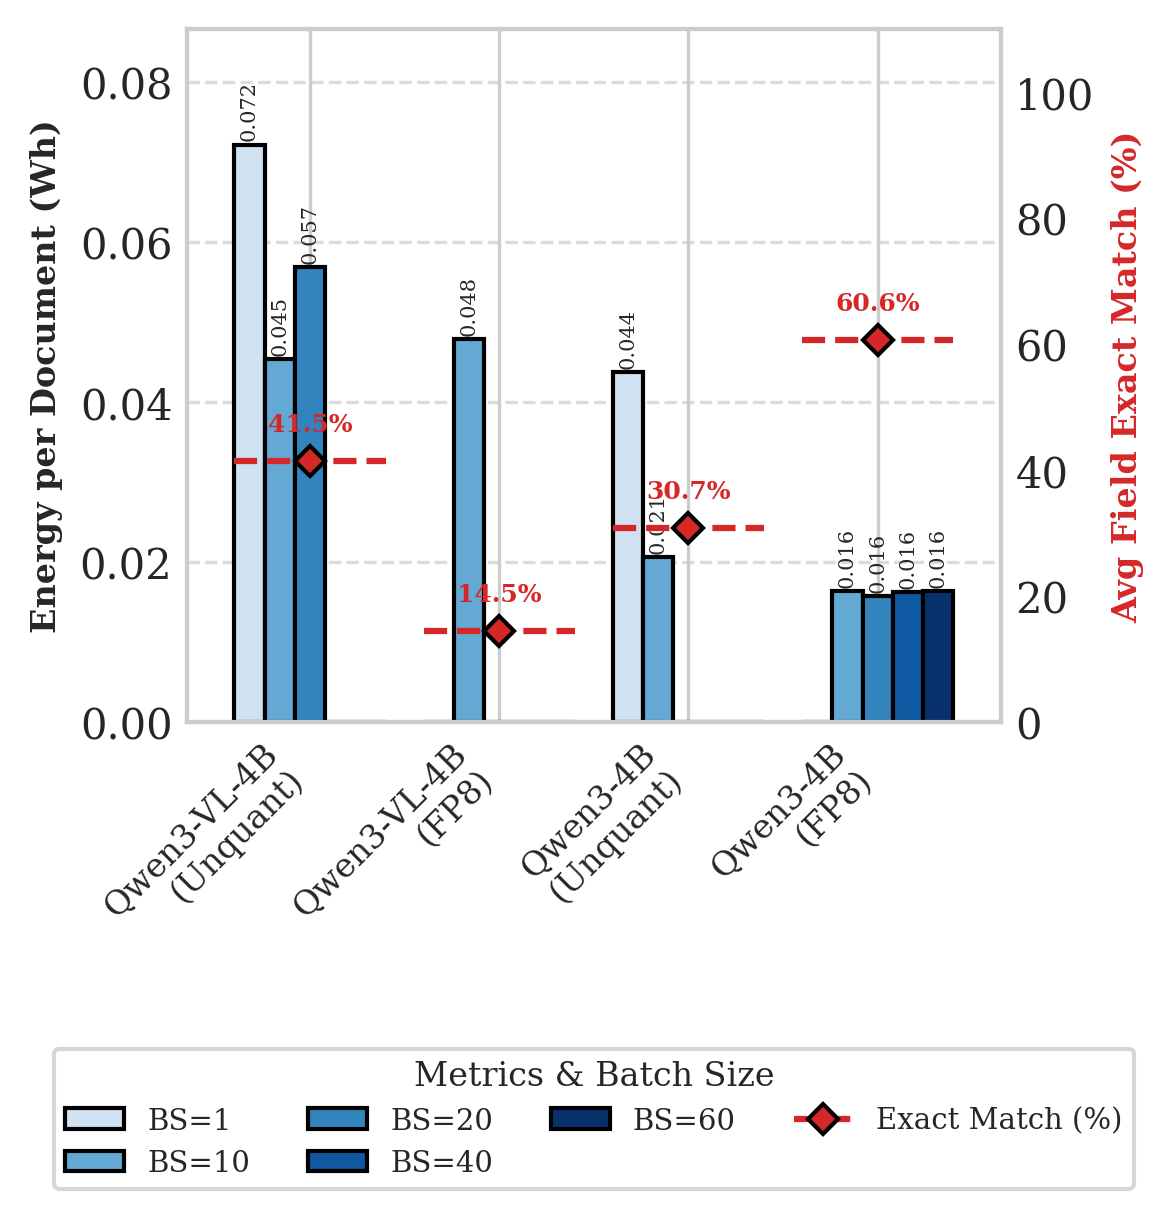

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Safely add Quantization tag directly using df_all's File_Path
def get_quant_status(path):
    path_str = str(path).lower()
    if 'noquant' in path_str:
        return 'Unquantized'
    elif 'quant' in path_str:
        return 'FP8 Quantized'
    return 'Unquantized'

# We use df_all directly to ensure File_Path is available for mapping
df_rq3_base = df_all.copy()
if 'File_Path' in df_rq3_base.columns:
    df_rq3_base['Quantization'] = df_rq3_base['File_Path'].apply(get_quant_status)
else:
    df_rq3_base['Quantization'] = 'Unquantized'

# 2. Strict Filter: Qwen3-4B (Tesseract) & Qwen3-VL-4B-Instruct (Vision)
is_vision = (df_rq3_base['Model'] == 'Qwen3-VL-4B-Instruct') & (df_rq3_base['Modality'] == 'Vision')
is_text_tesseract = (df_rq3_base['Model'] == 'Qwen3-4B') & \
                     (df_rq3_base['Modality'] == 'Text-Only') & \
                     (df_rq3_base['Task'].astype(str).str.lower() == 'tesseract')

df_rq3 = df_rq3_base[is_vision | is_text_tesseract].copy()

# 3. Create a shortened composite name for the X-axis grouping to save space
short_model = df_rq3['Model'].str.replace('-Instruct', '', regex=False)
short_quant = df_rq3['Quantization'].str.replace('Unquantized', 'Unquant').str.replace('FP8 Quantized', 'FP8')
df_rq3['Model_Quant'] = short_model + "\n(" + short_quant + ")"

# --- SET TEST SET SIZES FOR NORMALIZATION ---
TEST_SET_SIZES = {
    'VRDU': 500,
    'Kleister NDA': 337
}

# 4. COLOR PALETTE
all_unique_bs = sorted(df_rq3['Batch_Size'].dropna().unique())
cmap = plt.get_cmap('Blues')
color_array = cmap(np.linspace(0.2, 1.0, len(all_unique_bs)))
bs_color_map = {f"BS={int(bs)}": color_array[i] for i, bs in enumerate(all_unique_bs)}

# 5. GENERATE PLOTS
for dataset_name in ['VRDU', 'Kleister NDA']:
    df_compare = df_rq3[df_rq3['Dataset'] == dataset_name].copy()

    if df_compare.empty:
        continue

    # NORMALIZE ENERGY HERE BEFORE GROUPING
    df_compare['Energy_per_Doc_Wh'] = df_compare.apply(
        lambda row: row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1), axis=1
    )

    # Group Energy by our new composite Model_Quant column and Batch_Size
    df_grouped = df_compare.groupby(['Model_Quant', 'Batch_Size'])['Energy_per_Doc_Wh'].min().unstack().fillna(0)
    df_grouped.columns = [f"BS={int(c)}" for c in df_grouped.columns]

    # Group Exact Match Accuracy for the overlay
    df_acc = df_compare.groupby(['Model_Quant', 'Batch_Size'])['Exact_Match'].mean().unstack().fillna(0)
    df_acc.columns = [f"BS={int(c)}" for c in df_acc.columns]

    # Sort the index so Unquantized and FP8 Quantized appear next to each other alphabetically
    df_grouped = df_grouped.sort_index(ascending=False)
    df_acc = df_acc.loc[df_grouped.index]

    # Set figure size to ACL single-column width (approx 3.5 inches)
    fig, ax1 = plt.subplots(figsize=(3.5, 3.0))
    colors = [bs_color_map.get(col, 'gray') for col in df_grouped.columns]

    # Plot Energy Bars
    df_grouped.plot(kind='bar', color=colors, edgecolor='black', width=0.8, ax=ax1, zorder=3)

    # Update labels and remove title
    ax1.set_xlabel('')  # Removes the "Model_Quant" text at the bottom
    ax1.set_ylabel('Energy per Document (Wh)', fontweight='bold', fontsize=8)

    # Smaller font and adjusted rotation for narrow columns
    ax1.set_xticklabels(df_grouped.index, rotation=45, ha='right', fontsize=8)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

    # --- ADD ACCURACY TO SECONDARY Y-AXIS (CLEANER APPROACH WITH LABELS) ---
    ax2 = ax1.twinx()
    ax2.set_ylabel('Avg Field Exact Match (%)', fontweight='bold', color='#d62728', fontsize=8)
    ax2.set_ylim(0, 110)
    ax2.grid(False)

    # Plot a single centered line/marker and the text value per bar group
    x_positions = np.arange(len(df_grouped.index))

    for idx, model_name in enumerate(df_grouped.index):
        # Accuracy is constant across batch sizes, so take the mean for this group
        y_acc_val = df_acc.loc[model_name].mean()

        # 1. Draw a horizontal dashed line spanning the width of the bar group
        ax2.hlines(y=y_acc_val, xmin=idx - 0.4, xmax=idx + 0.4,
                   color='#d62728', linewidth=1.5, linestyle='--', zorder=4)

        # 2. Place a single prominent diamond marker in the exact center
        ax2.plot(idx, y_acc_val, marker='D', markersize=5,
                 color='#d62728', markeredgecolor='black', zorder=5)

        # 3. Add the exact match percentage text right above the diamond
        ax2.annotate(f'{y_acc_val:.1f}%',
                     xy=(idx, y_acc_val),
                     xytext=(0, 6), # 6 points vertical offset
                     textcoords='offset points',
                     ha='center',
                     va='bottom',
                     fontsize=6,
                     fontweight='bold',
                     color='#d62728',
                     zorder=6)

    # 6. ALL DATA LABELS FOR ENERGY
    for col_idx, container in enumerate(ax1.containers):
        labels = []
        for row_idx, rect in enumerate(container):
            val = rect.get_height()

            # Add label for every non-zero bar, rounded to 3 decimal places
            if val > 0:
                labels.append(f'{val:.3f}')
            else:
                labels.append('')

        # Reduce padding and fontsize for the narrow bars
        ax1.bar_label(container, labels=labels, padding=1, rotation=90, fontsize=5)

    # Consolidate Legends
    handles1, labels1 = ax1.get_legend_handles_labels()

    # Update the custom handle to match the aesthetic
    acc_patch = Line2D([0], [0], marker='D', color='#d62728', markerfacecolor='#d62728',
                       markeredgecolor='black', markersize=5, linestyle='--',
                       linewidth=1.5, label='Exact Match (%)')
    handles1.append(acc_patch)
    labels1.append('Exact Match (%)')

    # Place legend at the bottom across 4 columns
    ax1.legend(handles=handles1, labels=labels1, title='Metrics & Batch Size',
               loc='upper center', bbox_to_anchor=(0.5, -0.45), ncol=4,
               fontsize=7, title_fontsize=8, frameon=True, shadow=False)

    ax1.margins(y=0.2)

    # Save the figure. bbox_inches='tight' ensures the bottom legend is not cut off.
    filename = f'acl_rq3_qwen_quant_batch_acc_labeled_all_energy_{dataset_name.lower().replace(" ", "_")}.pdf'
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

In [21]:
import pandas as pd

# 1. Filter the dataset for Text-Only (with specific OCR tasks) and Vision models
valid_ocr_tasks = ['tesseract', 'deepseek', 'docling']

# Keep Vision models OR Text-Only models with the valid OCR tasks
mask = (df_all['Modality'] == 'Vision') | \
       ((df_all['Modality'] == 'Text-Only') & (df_all['Task'].astype(str).str.lower().isin(valid_ocr_tasks)))
df_table = df_all[mask].copy()

# 2. Calculate End-to-End Energy and OCR Energy per document
# Utilizing the TEST_SET_SIZES dictionary defined in your notebook[cite: 1]
TEST_SET_SIZES = {'VRDU': 500, 'Kleister NDA': 337}

def extract_ocr_energy(row):
    """Fetch OCR energy, returning 0 for Vision models."""
    if row['Modality'] == 'Vision':
        return 0.0

    dataset = row['Dataset']
    task = str(row['Task']).lower()
    # Ensure get_ocr_energy_per_doc is defined in your environment
    try:
        return get_ocr_energy_per_doc(dataset, task)
    except NameError:
        print(f"Warning: get_ocr_energy_per_doc missing. Defaulting to 0.0 for {task}")
        return 0.0

def calc_e2e_energy(row, ocr_energy):
    """Calculate base energy per doc plus OCR overhead."""
    base_energy_per_doc = row['Energy_Wh'] / TEST_SET_SIZES.get(row['Dataset'], 1)
    return base_energy_per_doc + ocr_energy

if not df_table.empty:
    df_table['OCR_Energy_Wh'] = df_table.apply(extract_ocr_energy, axis=1)
    df_table['Total_E2E_Energy_Wh'] = df_table.apply(lambda r: calc_e2e_energy(r, r['OCR_Energy_Wh']), axis=1)

    # Handle OCR Version label for Vision models (leave it blank/as a dash)
    df_table['Task_Clean'] = df_table.apply(
        lambda r: '--' if r['Modality'] == 'Vision' else r.get('Task_Clean', r['Task']), axis=1
    )

# 3. Sort and deduplicate to get the best configuration per Model, OCR Version, and Batch Size
df_table = df_table.sort_values(
    by=['Model', 'Task_Clean', 'Batch_Size', 'Exact_Match'],
    ascending=[True, True, True, False]
).drop_duplicates(subset=['Model', 'Task_Clean', 'Batch_Size'], keep='first')

# 4. Select and rename columns for the final LaTeX output
latex_df = df_table[[
    'Model',
    'Batch_Size',
    'Task_Clean',
    'Exact_Match',
    'Fuzzy_Match',
    'F1_Score',
    'OCR_Energy_Wh',
    'Total_E2E_Energy_Wh'
]].copy()

latex_df.rename(columns={
    'Batch_Size': 'Batch Size',
    'Task_Clean': 'OCR Version',
    'Exact_Match': 'Exact Match (\\%)',
    'Fuzzy_Match': 'Fuzzy Match (\\%)',
    'F1_Score': 'F1 Score (\\%)',
    'OCR_Energy_Wh': 'OCR Energy (Wh)',
    'Total_E2E_Energy_Wh': 'Total E2E Energy (Wh)'
}, inplace=True)

# Format the Batch Size to be an integer (removes the .0 if it loaded as a float)[cite: 1]
latex_df['Batch Size'] = latex_df['Batch Size'].astype(int)

# 5. Generate and print the LaTeX code using pandas
latex_table = latex_df.to_latex(
    index=False,
    float_format="%.2f",
    column_format="lcccccc", # 1 left-aligned text column, 6 center-aligned columns
    escape=False # Prevents pandas from escaping the \% symbol in headers
)

print(latex_table)

\begin{tabular}{lcccccc}
\toprule
Model & Batch Size & OCR Version & Exact Match (\%) & Fuzzy Match (\%) & F1 Score (\%) & OCR Energy (Wh) & Total E2E Energy (Wh) \\
\midrule
Arctic-Tilt & 1 & DeepSeek OCR & 81.47 & 91.24 & 84.84 & 0.00 & 0.00 \\
Arctic-Tilt & 10 & DeepSeek OCR & 81.47 & 91.24 & 84.84 & 0.00 & 0.00 \\
Arctic-Tilt & 1 & Docling & 91.91 & 97.95 & 93.78 & 0.00 & 0.04 \\
Arctic-Tilt & 10 & Docling & 91.91 & 97.95 & 93.78 & 0.00 & 0.04 \\
Arctic-Tilt & 1 & tesseract & 92.43 & 98.08 & 93.81 & 0.00 & 0.04 \\
Arctic-Tilt & 10 & tesseract & 92.43 & 98.08 & 93.81 & 0.00 & 0.04 \\
InternVL3_5-4B & 10 & -- & 65.58 & 88.54 & 73.21 & 0.00 & 0.05 \\
Llama-3.2-1B-Instruct & 1 & DeepSeek OCR & 9.87 & 12.18 & 8.64 & 0.00 & 0.01 \\
Llama-3.2-1B-Instruct & 5 & DeepSeek OCR & 12.30 & 15.36 & 10.92 & 0.00 & 0.01 \\
Llama-3.2-1B-Instruct & 10 & DeepSeek OCR & 47.55 & 70.70 & 58.35 & 0.00 & 0.01 \\
Llama-3.2-1B-Instruct & 20 & DeepSeek OCR & 44.44 & 68.30 & 56.41 & 0.00 & 0.01 \\
Llama-3.2-1B